# Cyclic Loading of Porous Rock — Modified Cam Clay with Viscoplasticity
## **Test Case 1: Clay-rich Sandstone** | Brine & H₂ Saturated | 100 / 200 / 300 bar

---

### Notebook structure

| Cell | Content |
|------|---------|
| **Cell 1** | Imports & global settings |
| **Cell 2** | Experimental data (per-cycle inelastic strain increments) |
| **Cell 3** | Power-law monotone fit of experimental curves |
| **Cell 4** | MCC viscoplastic simulator (constitutive model) |
| **Cell 5** | Log-space calibration algorithm |
| **Cell 6** | Run calibration for all 6 cases |
| **Cell 7** | Calibrated parameter summary table |
| **Cell 8** | Main figure — cumulative inelastic strain |
| **Cell 9** | Per-cycle strain increments |
| **Cell 10** | Brine vs H₂ strain difference |
| **Cell 11** | Pressure sensitivity |
| **Cell 12** | Calibration diagnostics |
| **Cell 13** | Calibrated parameter radar chart |


---

### Governing constitutive equations

**Modified Cam Clay yield surface:**
$$F(p', q, p_c) = p'^2 - p' p_c + \frac{q^2}{M^2} = 0$$

**Plastic consistency condition (stress-path prescribed):**
$$\Omega = \frac{\lambda - \kappa}{(1+e) \, p' \, (M^2 + \eta^2)}, \qquad \eta = q/p'$$

$$d\varepsilon_v^p = \Omega \left[(M^2 - \eta^2)\,dp' + 2\eta\,dq\right]$$

**Isotropic hardening:**
$$p_c^{n+1} = p_c^n \left(\frac{p'_{\text{new}}}{p_c^n}\right)^\theta$$

**Viscoplastic (creep) strain rate:**
$$\dot{\varepsilon}^{vp} = \frac{\langle F \rangle^{n}}{\eta_v}, \qquad \langle F \rangle = \frac{\max(F,0)}{p_c^2}$$

**Cumulative inelastic axial strain:**
$$\Sigma\varepsilon_1^{inel}(N) = \sum_{j=1}^{N} \varepsilon_1^{inel}(j)$$

**Parameters calibrated:** $M,\;\lambda,\;\kappa,\;\theta,\;p_{c0},\;\eta_v,\;n$

---

> **Output folder:** All figures are saved in `Outputs_Calibration_Clay_Rich/` with descriptive names,
> e.g. `Cell08_Cumulative_Strain.png`, `Cell11_Pressure_Sensitivity.png`, etc.


## Cell 1 — Imports & Global Settings

Standard scientific Python stack. All packages are available in any Jupyter environment.

### Packages used
| Package | Purpose |
|---------|---------|
| `numpy` | Array operations, linear algebra |
| `scipy.optimize` | Calibration: Trust-Region Reflective (TRF) + L-BFGS-B |
| `matplotlib` | All plotting (figures saved to `Outputs_Calibration_Clay_Rich/`) |
| `warnings`, `time`, `sys` | Standard library utilities |

### Global plot style
- `figure.dpi = 120` for retina-quality inline display
- `savefig.dpi = 300` for publication-quality saved files
- Colour palette: blue=100 bar, green=200 bar, red=300 bar


In [33]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings                          # suppress non-critical scipy/numpy deprecation warnings from output
import sys                               # used below to print the Python version as a sanity check
import time                              # used to measure wall-clock run-time during calibration
import os                                # used to create the 'Outputs_Calibration_Clay_Rich/' folder on disk

# ── Numerical & optimisation ──────────────────────────────────────────────────
import numpy as np                       # array maths, linear algebra, random numbers – used everywhere
from scipy.optimize import (             # two optimisers for the two-stage calibration in Cell 5
    least_squares,                       #   Trust-Region Reflective (TRF): handles box parameter bounds
    minimize                             #   L-BFGS-B quasi-Newton polish: refines the best TRF result
)

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt          # main plotting engine for all figures
import matplotlib.ticker as mticker      # fine-grained tick control (MultipleLocator for integer cycles)
from matplotlib.lines import Line2D      # used to create custom line/marker legend entries manually
from matplotlib.gridspec import GridSpec # flexible subplot grid – used for multi-panel figures

# ── Output directory (all figures saved here) ─────────────────────────────────
OUTPUT_DIR = 'Outputs_Calibration_Clay_Rich'                   # sub-folder name where every PDF and PNG will be written
os.makedirs(OUTPUT_DIR, exist_ok=True)  # create the folder if it does not exist; no error if it already does

def savefig(fig, name):
    """Save figure as both PDF (vector) and PNG (300 dpi raster) to Outputs_Calibration_Clay_Rich/.
    Parameters: fig = matplotlib Figure; name = base filename without extension."""
    base = os.path.join(OUTPUT_DIR, name)               # full path, e.g. 'Outputs_Calibration_Clay_Rich/Cell08_Cumulative_Strain'
    fig.savefig(base + '.pdf', bbox_inches='tight')     # vector PDF – best for LaTeX / publications
    fig.savefig(base + '.png', dpi=300, bbox_inches='tight')  # raster PNG – 300 dpi publication quality
    print(f'Saved: {base}.pdf / .png  \u2713')

# ── Global plot style ─────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')        # silence scipy/numpy deprecation messages in output cells
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',  # clean, cross-platform sans-serif font
    'font.size'        : 11,             # base font size in points (applies to tick labels)
    'axes.titlesize'   : 12,             # title of each subplot
    'axes.labelsize'   : 12,             # x-axis and y-axis labels
    'axes.labelweight' : 'bold',         # bold axis labels for clarity in small panels
    'axes.grid'        : True,           # show reference grid on every axis
    'grid.alpha'       : 0.35,           # grid transparency – subtle, does not compete with data
    'grid.linestyle'   : '--',           # dashed grid lines (standard scientific style)
    'legend.fontsize'  : 8.5,            # legend text smaller than axis labels
    'legend.framealpha': 0.92,           # slightly transparent legend background box
    'figure.dpi'       : 120,            # screen display resolution (retina quality in Jupyter)
    'savefig.dpi'      : 300,            # file save resolution (publication quality)
    'savefig.bbox'     : 'tight',        # auto-crop white border when saving
})

# ── Colour palette (consistent across all 14 cells) ──────────────────────────
COLOR = {
    '100 bar': '#1565C0',                # deep blue   – visually distinct, print-safe
    '200 bar': '#2E7D32',                # deep green  – visually distinct, print-safe
    '300 bar': '#C62828',                # deep red    – visually distinct, print-safe
}

# ── Sanity-check output ───────────────────────────────────────────────────────
print(f'Python  : {sys.version.split()[0]}')   # confirm Python version
print(f'NumPy   : {np.__version__}')            # confirm NumPy version
print('Imports : OK \u2713')


Python  : 3.13.1
NumPy   : 2.4.1
Imports : OK ✓


## Cell 2 - Experimental Data

### What data is stored here and where does it come from?

The arrays `exp_per_brine` and `exp_per_h2` contain **per-cycle inelastic axial strain increments** $\varepsilon_1^{inel}(j)$ measured from **cyclic triaxial compression tests** on clay-rich rock samples. Each value represents how much permanent (irreversible) axial deformation occurred during one loading cycle.

---

### How was the experiment done?

#### Test setup - Cyclic triaxial apparatus

```
      ↑  Axial load σ₁ (cycled)
      │
  ┌───┴───┐
  │  Rock │  ← clay-rich sample (cylindrical core)
  │ sample│  ← saturated with Brine or H₂ at given pressure
  └───────┘
      ↕
  σ₃ = confining pressure (constant, applied by fluid in cell)
```

| Parameter | Value |
|-----------|-------|
| Confining pressure $\sigma_3$ | 10, 20, 30 MPa |
| Mean axial stress | 38 MPa |
| Cyclic amplitude | ±20 MPa |
| Peak deviatoric stress $q_{max}$ | $(\sigma_1 - \sigma_3)_{max}$ ≈ 48 MPa |
| Hold time at peak | 600 s (10 min) |
| Fluid | Brine (saline) or H₂ (hydrogen gas) |
| Fluid pressures tested | 100, 200, 300 bar |
| Number of cycles | 8 |

---

### How is inelastic strain measured?

During each loading cycle the axial deformation $\Delta L$ is measured by **LVDT sensors** (Linear Variable Differential Transducer) mounted on the sample. The axial strain is:

$$\varepsilon_1 = \frac{\Delta L}{L_0}$$

One complete cycle looks like this on a stress–strain curve:

```
  q [MPa]
  ^
  |          ★ peak (hold 600s)
  |         /  \
  |        /    \
  |       /      \
  |      /        \
  |─────/──────────\────→ ε₁
       ↑            ↑
   start of       end of
   cycle j        cycle j
       |←─ Δε₁ᵉ ─→|← Δε₁ⁱⁿᵉˡ →|
```

- **Elastic strain** $\Delta\varepsilon_1^e$: recovers when load is removed (reversible)
- **Inelastic strain** $\Delta\varepsilon_1^{inel}$: permanent offset - does NOT recover

The **inelastic increment per cycle** is the difference in axial position before and after one complete cycle:

$$\boxed{\varepsilon_1^{inel}(j) = \varepsilon_1^{\text{end of cycle }j} - \varepsilon_1^{\text{start of cycle }j}}$$

This is what is stored in `exp_per_brine` and `exp_per_h2`.

---

### Why is the first value always 0.0?

```python
'100 bar': np.array([0.0, 1.40902e-03, 6.33e-06, ...])
#                    ↑
#             cycle 1 = reference (no prior deformation)
```

The first value is **defined as zero** because cycle 1 is the reference state. All subsequent values measure deformation **relative to the initial state**. This is a standard convention in cyclic rock mechanics - you cannot measure deformation "before" the first cycle.

---

### The cumulative sum: why use `np.cumsum`?

The **cumulative inelastic strain** plotted on the y-axis is:

$$\Sigma\varepsilon_1^{inel}(N) = \sum_{j=1}^{N} \varepsilon_1^{inel}(j)$$

In Python:

```python
exp_cum_brine = {k: np.cumsum(v) for k, v in exp_per_brine.items()}
```

Example for Brine 100 bar:
```
per_cycle:   [0.0,   0.001409,  0.0000063, 0.0000636, ...]
cumsum:      [0.0,   0.001409,  0.001415,  0.001479,  ...]
             cycle1  cycle2      cycle3     cycle4
```

The cumulative strain **always increases** - each cycle adds a non-negative amount.

---

### How are the MCC parameters obtained from this data?

The experimental cumulative strain data is used to **calibrate** (fit) the 7 MCC parameters $\{M, \lambda, \kappa, \theta, p_{c0}, \eta_v, n\}$ through an inverse analysis. The process is:

#### Step 1 - Fit a power-law to the experimental data (Cell 3)

$$\Sigma\varepsilon_1^{inel}(N) \approx a \cdot N^b, \qquad 0 < b < 1$$

This smooth curve represents the "true" experimental behaviour, filtering measurement noise.

#### Step 2 - Define a loss function (Cell 5)

$$\mathcal{L}(\mathbf{x}) = \frac{1}{N_{pts}} \sum_{i} \left[\log_{10}\varepsilon^{num}(N_i) - \log_{10}\varepsilon^{fit}(N_i)\right]^2$$

where $\mathbf{x} = \{M, \lambda, \kappa, \theta, p_{c0}, \eta_v, n\}$ and $\varepsilon^{num}$ comes from the MCC simulator.

#### Step 3 - Minimise the loss (Cell 6)

$$\mathbf{x}^* = \arg\min_{\mathbf{x}} \mathcal{L}(\mathbf{x}), \quad \mathbf{x} \in [\mathbf{x}^{lo}, \mathbf{x}^{hi}]$$

Solved by multi-start TRF + L-BFGS-B in log₁₀ parameter space (Cell 5).

#### Step 4 - Physical meaning of calibrated parameters

| Parameter | Controls | If it increases |
|-----------|---------|----------------|
| $M$ | Size of yield surface | Larger $M$ → smaller plastic zone → less strain |
| $\lambda$ | Plastic compressibility | Larger $\lambda$ → more plastic strain per cycle |
| $\kappa$ | Elastic stiffness | Larger $\kappa$ → more elastic, less plastic |
| $\theta$ | Softening after yield | Larger $\theta$ → more post-yield weakening |
| $p_{c0}$ | Initial hardness | Larger $p_{c0}$ → harder → less strain cycle 1 |
| $\eta_v$ | Viscoplastic resistance | Larger $\eta_v$ → less creep → less total strain |
| $n$ | Creep rate sensitivity | Larger $n$ → creep turns on faster above yield |

---

### Full inelastic strain formulation

The total inelastic axial strain per cycle comes from three mechanisms:

$$\varepsilon_1^{inel}(j) = \underbrace{\int_{\text{cycle}} d\varepsilon_1^p}_{\text{MCC plastic}} + \underbrace{\int_{\text{loading}} \dot{\varepsilon}^{vp}\, dt}_{\text{VP during loading}} + \underbrace{\dot{\varepsilon}^{vp}\big|_{\text{peak}} \cdot t_{hold}}_{\text{VP during hold}}$$

**Mechanism 1 - MCC plastic strain** (when stress exceeds yield surface $F > 0$):

$$d\varepsilon_1^p = \frac{d\varepsilon_v^p}{3} + d\varepsilon_s^p$$

$$d\varepsilon_v^p = \Omega \left[(M^2 - \eta^2)\,dp' + 2\eta\,dq\right], \quad \Omega = \frac{\lambda - \kappa}{(1+e)\,p'\,(M^2+\eta^2)}$$

**Mechanism 2 - Viscoplastic creep rate** (Perzyna overstress):

$$\dot{\varepsilon}^{vp} = \frac{1}{\eta_v}\left\langle \frac{F(p',q,p_c)}{p_c^2} \right\rangle^n, \qquad \langle x \rangle = \max(x, 0)$$

**Isotropic hardening** (makes the material stiffer each cycle):

$$p_c^{j+1} = p_c^j + \frac{1+e}{\lambda - \kappa} \cdot p_c^j \cdot d\varepsilon_v^p$$

The hardening means $\varepsilon_1^{inel}(j)$ **decreases** with cycle number $j$ - explaining the concave (power-law) shape of the cumulative curve.

---

### How to replace this data with your own measurements

If you have your own Excel data, replace `exp_per_brine` and `exp_per_h2` with:

```python
import pandas as pd

# Excel file format required:
# Sheet "Brine": columns [Cycle, 100bar, 200bar, 300bar]
# Sheet "H2":   columns [Cycle, 100bar, 200bar, 300bar]
# Values = per-cycle inelastic strain increments (dimensionless)
# First value in each column = 0.0 (reference)

df_b = pd.read_excel('your_data.xlsx', sheet_name='Brine')
df_h = pd.read_excel('your_data.xlsx', sheet_name='H2')

exp_per_brine = {
    '100 bar': df_b['100bar'].values,
    '200 bar': df_b['200bar'].values,
    '300 bar': df_b['300bar'].values,
}
exp_per_h2 = {
    '100 bar': df_h['100bar'].values,
    '200 bar': df_h['200bar'].values,
    '300 bar': df_h['300bar'].values,
}
```


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — EXPERIMENTAL DATA  (Test Case 2: Quartz-rich Sandstone)
# Purpose : Store the raw per-cycle inelastic axial strain increments measured
#           in the laboratory for both fluid saturations and three pressures.
#           Convert them to cumulative sums ready for plotting and calibration.
# ══════════════════════════════════════════════════════════════════

# ── Problem dimensions ───────────────────────────────────────────────────────
Ncycle    = 8                                        # total number of loading cycles per test
cycles    = np.arange(1, Ncycle + 1, dtype=float)   # cycle index array [1.0, 2.0, ..., 8.0] – used as x-axis
pressures = ['100 bar', '200 bar', '300 bar']        # string labels for the three confining pressures tested

# ── Per-cycle inelastic axial strain increments – BRINE saturation ────────────
# TEST CASE 1 : Clay-rich Sandstone
# Each array has 8 values – one per cycle.
#   value[j] = permanent (inelastic) axial strain added during loading cycle j [dimensionless]
# First entry is ALWAYS 0.0 because cycle 1 is the reference state (no prior deformation).
# Raw unit: dimensionless strain = ΔL / L₀  (e.g. 1.40902e-03 ≈ 0.14 % compression)
exp_per_brine = {
    '100 bar': np.array([0.0, 1.40902e-03, 6.33000e-06, 6.35700e-05,
                         6.92600e-05, 8.44800e-05, 2.88780e-04, 2.43000e-05]),  # Brine @ 100 bar, cycles 1-8
    '200 bar': np.array([0.0, 1.33122e-03, 2.45880e-04, 3.51440e-04,
                         3.28000e-05, 3.31600e-05, 2.43080e-04, 3.11900e-05]),  # Brine @ 200 bar, cycles 1-8
    '300 bar': np.array([0.0, 9.29130e-04, 3.17890e-04, 8.48900e-05,
                         7.01000e-06, 6.58300e-05, 2.32000e-06, 7.16200e-05]),  # Brine @ 300 bar, cycles 1-8
}

# ── Per-cycle inelastic axial strain increments – H₂ saturation ──────────────
# Same measurement format as exp_per_brine but for hydrogen-saturated samples.
# Differences between Brine and H₂ reflect the fluid–rock interaction effect.
exp_per_h2 = {
    '100 bar': np.array([0.0, 6.57520e-04, 6.36710e-04, 4.05000e-05,
                         3.12000e-05, 5.74000e-06, 9.73400e-05, 5.29300e-05]),  # H₂ @ 100 bar, cycles 1-8
    '200 bar': np.array([0.0, 1.68054e-03, 1.00010e-04, 1.73790e-04,
                         2.18670e-04, 4.85600e-05, 2.26800e-05, 1.40130e-04]),  # H₂ @ 200 bar, cycles 1-8
    '300 bar': np.array([0.0, 1.42021e-03, 4.71100e-05, 9.72300e-05,
                         3.94500e-05, 5.08000e-05, 1.18600e-05, 3.73400e-05]),  # H₂ @ 300 bar, cycles 1-8
}

# ── Convert to cumulative sums (what is plotted on the y-axis) ───────────────
# np.cumsum([0, a, b, c]) = [0, a, a+b, a+b+c]
# Turns per-cycle increments into a running total of permanent deformation.
# The result is monotone-increasing: each cycle can only ADD deformation.
exp_cum_brine = {k: np.cumsum(v) for k, v in exp_per_brine.items()}  # cumulative strain vs cycle – Brine
exp_cum_h2    = {k: np.cumsum(v) for k, v in exp_per_h2.items()}     # cumulative strain vs cycle – H₂

# ── Convenience helper: return cumulative array for any fluid/pressure ────────
def exp_cum(fluid, p):
    """Return experimental cumulative strain array. fluid='Brine' or 'H2'; p e.g. '100 bar'."""
    return exp_cum_brine[p] if fluid == 'Brine' else exp_cum_h2[p]  # dispatch on fluid type

# ── Print data summary ────────────────────────────────────────────────────────
print('Cumulative strain at cycle 8 [%]:')
print(f'{"":12} {"100 bar":>10} {"200 bar":>10} {"300 bar":>10}')
print('-'*45)
for fluid, data in [('Brine', exp_cum_brine), ('H2', exp_cum_h2)]:
    vals = [f"{data[p][-1]*100:.4f}" for p in pressures]  # last element = cycle 8; ×100 converts to %
    print(f'{fluid:<12} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}')
print('Data loaded \u2713')


Cumulative strain at cycle 8 [%]:
                100 bar    200 bar    300 bar
---------------------------------------------
Brine            0.1946     0.2269     0.1479
H2               0.1522     0.2384     0.1704
Data loaded ✓


## Cell 3 — Power-Law Monotone Fit

The experimental cumulative strain follows a **power-law** form:
$$\Sigma\varepsilon_1^{inel}(N) = \varepsilon_0 + a\,(N - N_0)^b, \qquad b < 1$$

This is fitted in log–log space using linear regression:
$$\ln(\Sigma\varepsilon - \varepsilon_0) = \ln(a) + b \ln(N - N_0)$$

### Key constraint
The **monotone constraint** (`np.maximum.accumulate`) ensures the fit never decreases —
physically required for cumulative inelastic strain (each cycle can only add deformation,
never remove it).

### Exponent $b$
- $b < 1$: decelerating growth (concave up) — expected for hardening materials
- $b > 1$: accelerating growth — would indicate softening / damage
- $b = 1$: linear accumulation


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — POWER-LAW MONOTONE FIT
# Purpose : Fit a smooth y = y0 + a*(x-x0)^b curve through the experimental
#           cumulative strain data.  The exponent b is found by linear
#           regression in log–log space; monotonicity is enforced by
#           np.maximum.accumulate so the fit never decreases (physical constraint).
# ══════════════════════════════════════════════════════════════════════════════

def powerlaw_fit_monotone(x, y, npts=2500):
    """
    Fit a monotone power-law curve through cumulative experimental data.

    Model:  y = y0 + a * (x - x0)^b

    The exponent b is found by linear regression in log-log space:
        log(y - y0) = log(a) + b * log(x - x0)
    where b < 1 means decelerating growth (isotropic hardening).

    Monotone constraint via np.maximum.accumulate ensures the output
    curve never decreases – physically required for cumulative strain.

    Parameters
    ----------
    x    : cycle indices [1..8]
    y    : cumulative strain values
    npts : number of output points for smooth curve (default 2500)

    Returns
    -------
    x_line : dense x array between x[0] and x[-1]
    y_line : fitted y values with monotonicity enforced
    """
    x, y = np.asarray(x, float), np.asarray(y, float)  # ensure 1-D float arrays
    x0, y0 = x[0], y[0]                                 # anchor point = cycle 1 (reference state)
    dx, dy  = x - x0, y - y0                            # increments from anchor; both ≥ 0 for valid data
    mask    = (dx > 0) & (dy > 0)                        # mask excludes anchor (dx=0) and flat entries (dy=0)

    if mask.sum() < 2:                                   # fallback when fewer than 2 points usable for log-fit
        xl = np.linspace(x[0], x[-1], npts)             # use linear spacing over full cycle range
        return xl, np.maximum.accumulate(np.interp(xl, x, y))  # linear interp + monotone enforcement

    # Linear regression in log-log space: log(dy) = log(a) + b*log(dx)
    b, log_a = np.polyfit(np.log(dx[mask]), np.log(dy[mask]), 1)  # deg-1 poly = line → [slope, intercept]
    a        = np.exp(log_a)                             # recover amplitude a from log(a)

    xl = np.linspace(x[0], x[-1], npts)                 # dense output grid for smooth plotting
    yl = y0 + a * np.maximum(xl - x0, 0.0)**b           # evaluate power-law; np.maximum clips negative (xl-x0) to 0
    return xl, np.maximum.accumulate(yl)                  # enforce monotonicity: each value ≥ all previous


# ── Verify fit exponents ─────────────────────────────────────────────────────
# All b values should be between 0 and 1 (decelerating growth = hardening)
print('Power-law fit exponents b (< 1 = decelerating growth):')
print(f'{"":12} {"100 bar":>10} {"200 bar":>10} {"300 bar":>10}')
print('-'*45)
for fluid, data in [('Brine', exp_cum_brine), ('H2', exp_cum_h2)]:
    exps = []                                            # collect exponent strings for this fluid
    for p in pressures:
        x, y = cycles, data[p]                          # cycle indices and cumulative strains
        dx, dy = x - x[0], y - y[0]                    # increments from reference point
        mask = (dx > 0) & (dy > 0)                      # exclude anchor and flat entries
        b, _ = np.polyfit(np.log(dx[mask]), np.log(dy[mask]), 1) if mask.sum() >= 2 else (0, 0)
        exps.append(f'{b:.3f}')                         # format exponent to 3 decimal places
    print(f'{fluid:<12} {exps[0]:>10} {exps[1]:>10} {exps[2]:>10}')
print('Fit function ready \u2713')


Power-law fit exponents b (< 1 = decelerating growth):
                100 bar    200 bar    300 bar
---------------------------------------------
Brine             0.170      0.276      0.214
H2                0.371      0.187      0.098
Fit function ready ✓


## Cell 4 — MCC Viscoplastic Simulator

### Physical model

The simulator implements **Modified Cam Clay (MCC)** coupled with a **Perzyna viscoplastic creep**
model under a **prescribed cyclic triaxial stress path**. Total inelastic strain per cycle:

$$\varepsilon_1^{inel}(j) = \varepsilon_1^{p} + \varepsilon_1^{vp,\,load} + \varepsilon_1^{vp,\,hold}$$

### Numerical method: Operator-Split (Mixed Explicit–Iterative)

| Component | Method | Details |
|-----------|--------|---------|
| Plastic strain | **Iterative consistency** | Fixed-point loop updating $p_c$ until $F \leq F_{tol}$ |
| $p_c$ hardening | **Semi-implicit** | Updated inside plastic loop using current $p_c$ |
| VP creep (loading) | **Explicit forward-Euler** | $d\varepsilon^{vp} = \dot{\varepsilon}^{vp} \cdot \Delta t$ |
| VP creep (hold) | **Explicit forward-Euler** | Fixed sub-steps at frozen peak stress |

### Stress path (per cycle)
1. **Loading:** $(p', q)$ from $(p'_i, 0)$ to $(p'_{max}, q_{max})$
2. **Hold:** stress frozen at peak — viscoplastic creep accumulates (600 s)
3. **Unloading:** stress returns to $(p'_i, 0)$

### Initial parameter table (physics-based guesses for calibration)

| Case | $\phi_0$ | $\lambda$ | $\kappa$ | $M$ | $\theta$ | $p_{c0}$ [MPa] |
|------|----------|-----------|----------|-----|----------|--------------|
| Brine 100 bar | 0.32 | 0.00285 | 0.00055 | 0.702 | 0.0045 | 13.0 |
| Brine 200 bar | 0.30 | 0.00220 | 0.00045 | 0.740 | 0.0045 | 26.0 |
| Brine 300 bar | 0.28 | 0.00190 | 0.00040 | 0.760 | 0.0045 | 39.0 |
| H₂ 100 bar | 0.33 | 0.003135 | 0.000605 | 0.682 | 0.0045 | 11.05 |
| H₂ 200 bar | 0.31 | 0.00242 | 0.000495 | 0.720 | 0.0045 | 22.10 |
| H₂ 300 bar | 0.29 | 0.00209 | 0.000440 | 0.740 | 0.0045 | 33.15 |



#### Plastic strain at each load step (consistency condition)
When $F > 0$ (yielding), the plastic strain increment is:
$$d\boldsymbol{\varepsilon}^p = \Omega \begin{bmatrix} M^2-\eta^2 & 2\eta \\ 2\eta & 4\eta^2/(M^2-\eta^2) \end{bmatrix} \begin{bmatrix} dp' \\ dq \end{bmatrix}$$

The hardening update uses the critical-state softening parameter $\theta$:
$$p_c^{\text{new}} = p_c^{\text{old}} \left(\frac{p'_{\text{ref}}}{p_c^{\text{old}}}\right)^\theta$$

#### Viscoplastic rate (Perzyna model)
$$\dot{\varepsilon}^{vp} = \frac{1}{\eta_v} \left\langle \frac{F}{p_c^2} \right\rangle^n$$

#### Speed note
`dp_step = 200 000 Pa` (coarse) gives ~90 ms/call and is used during calibration.  
After calibration, the same parameters can be run with `dp_step = 10 000 Pa` for higher accuracy.


## Cell 4 - MCC Viscoplastic Simulator - Overview

### Physical model overview

The simulator implements **Modified Cam Clay (MCC)** coupled with a **Perzyna viscoplastic creep** model under a **prescribed cyclic triaxial stress path**. The total inelastic strain per cycle is split into three contributions using an **operator-split** (also called a sequential) scheme:

$$\varepsilon_1^{inel}(j) = \varepsilon_1^{p} + \varepsilon_1^{vp,\,load} + \varepsilon_1^{vp,\,hold}$$

---

### Numerical method: Operator-Split (Mixed Explicit–Iterative)

This code uses a **mixed numerical strategy** - not purely explicit and not purely implicit. The three components are handled with different schemes:

| Component | Method | Details |
|-----------|--------|---------|
| Plastic strain | **Iterative consistency correction** | Fixed-point loop updating $p_c$ until $F \leq F_{tol}$ |
| $p_c$ hardening | **Semi-implicit** | Updated inside the plastic loop using current $p_c$ |
| Viscoplastic creep (loading) | **Explicit forward-Euler** | $d\varepsilon^{vp} = \dot{\varepsilon}^{vp}(\text{state}^n) \cdot \Delta t$ |
| Viscoplastic creep (hold) | **Explicit forward-Euler** | Fixed sub-steps at frozen stress state |



---

### Step-by-step: what happens at each loading increment

#### Step 1 - Evaluate yield function at state $n$

$$F_n = p_n'^2 - p_n' p_{c,n} + \frac{q_n^2}{M^2}$$

- If $F_n \leq 0$: the current stress state is **inside** the yield surface → **elastic step**, no plastic strain, skip to Step 4
- If $F_n > 0$: the stress state is **outside** the yield surface → **plastic step**, proceed to Step 2

**In the code:**
```python
F0 = yF(pdash[i], q[i], pc[i])
if not ((F0 < 0.0) and (j > 0)):   # plastic correction needed
```

---

#### Step 2 - Plastic strain via consistency condition (iterative)

The stress path is **prescribed** (not computed from elastic stiffness), so we use the **consistency condition** directly to find the plastic strain increment.

The plastic compliance scalar $\Omega$ controls how much strain is produced per unit stress increment:

$$\Omega = \frac{\lambda - \kappa}{(1+e)\, p'\, (M^2 + \eta^2)}, \qquad \eta = \frac{q}{p'}$$

The **plastic strain increment vector** $[d\varepsilon_v^p,\; d\varepsilon_s^p]^T$ from the 2×2 plastic compliance matrix:

$$\begin{bmatrix} d\varepsilon_v^p \\ d\varepsilon_s^p \end{bmatrix} = \Omega \underbrace{\begin{bmatrix} M^2 - \eta^2 & 2\eta \\ 2\eta & \dfrac{4\eta^2}{M^2 - \eta^2} \end{bmatrix}}_{\text{plastic compliance matrix}} \begin{bmatrix} dp' \\ dq \end{bmatrix}$$

The **inelastic axial strain increment** (what is plotted) combines volumetric and deviatoric parts:

$$d\varepsilon_1^p = \frac{d\varepsilon_v^p}{3} + d\varepsilon_s^p$$

**In the code:**
```python
Om  = (lam - kap) / ((1 + e_void) * pe * (M**2 + eta**2))
pm  = [[M²-η², 2η], [2η, 4η²/(M²-η²)]]     # plastic compliance matrix
dpp = Om * (pm @ vec)                          # plastic strain vector
de  = (dpp[0] + 3*dpp[1]) / 3                 # axial plastic strain
```

---

#### Step 3 - Isotropic hardening: update preconsolidation pressure $p_c$

After each plastic increment, $p_c$ increases (isotropic hardening) - this makes the rock stiffer for the next step:

$$p_c^{\text{new}} = p_c^{\text{old}} + \frac{1+e}{\lambda - \kappa} \cdot p_c^{\text{old}} \cdot d\varepsilon_v^p$$

Then a **softening correction** using the parameter $\theta$ is applied to model post-yield softening:

$$p_c^{\text{corrected}} = p_{c,\text{ref}} \left(\frac{p'_{\text{ref}}}{p_{c,\text{ref}}}\right)^\theta$$

The **iterative loop** (up to 80 iterations) repeats Steps 2–3 until the updated state no longer violates the yield condition:

$$F(p', q, p_c^{\text{new}}) \leq 10^6 \quad \text{(convergence criterion)}$$

**In the code:**
```python
while Fi > 1e6 and it < 80:            # iterate until yield satisfied
    pc[i] += dpp[0] * (...) * pc[i]   # update pc (hardening)
    Fi = yF(pdash[i], q[i], pc[i])    # re-check yield
```

---

#### Step 4 - Viscoplastic creep rate during loading (Explicit Forward-Euler)

Even inside the elastic domain (or after plastic correction), viscoplastic creep occurs continuously. The **Perzyna overstress model** gives the creep strain rate:

$$\dot{\varepsilon}^{vp} = \frac{1}{\eta_v} \left\langle \frac{F}{p_c^2} \right\rangle^n, \qquad \langle x \rangle = \max(x, 0)$$

The creep increment over one loading time step $\Delta t_{load}$ is computed **explicitly**:

$$d\varepsilon^{vp}_{load} = \dot{\varepsilon}^{vp}(\text{state}^n) \cdot \Delta t_{load}$$

**Key:** This uses the strain rate evaluated at the **beginning** of the step (state $n$), not at the end - this is the definition of **forward-Euler (explicit)**. It is simple and fast, but requires small enough $\Delta t$ to remain stable.

**In the code:**
```python
Fn   = yF(pdash[i], q[i], pc[i])      # F at CURRENT state n
de_r = R(Fn, pc[i]) * dt_load         # explicit: rate × dt
```

---

#### Step 5 - Accumulate total inelastic strain

The total inelastic strain at step $i+1$ is the running sum:

$$\varepsilon_1^{inel}[i+1] = \varepsilon_1^{inel}[i] + |d\varepsilon_1^p| + |d\varepsilon^{vp}_{load}|$$

**In the code:**
```python
e_ax[i+1] = max(e_ax[i] + abs(de) + abs(de_r), 0.0)
```

---

#### Step 6 - Hold phase: viscoplastic creep at peak stress (Explicit Forward-Euler)

After loading to peak $(p'_{max}, q_{max})$, the sample is held at constant stress for time $t_{hold} = 600$ s. During this period, only viscoplastic creep occurs (no stress increment → no plastic strain):

$$\varepsilon_1^{vp,hold} = \sum_{k=1}^{N_{hold}} \dot{\varepsilon}^{vp}\big|_{\text{peak}} \cdot \Delta t_{hold}$$

where $\Delta t_{hold} = t_{hold} / N_{hold}$ and the rate is **frozen** at the peak stress state throughout the hold (consistent with forward-Euler).

**In the code:**
```python
dt_h = hold_time / hold_steps
for _ in range(hold_steps):
    Fh = yF(ph, qh, pch)          # F at peak (constant)
    eh += abs(R(Fh, pch) * dt_h)  # explicit: rate × dt_hold
```

---

#### Step 7 - End of cycle: pass $p_c$ forward

The final $p_c$ value at the end of cycle $j$ is passed as the **initial condition** for cycle $j+1$:

$$p_{c,0}^{(j+1)} = p_c^{\text{end}}(j)$$

This is how the **hardening memory** is preserved between cycles - the rock gets progressively stiffer.

**In the code:**
```python
pc_cycle = pc[min(count-1, len(pc)-1)]   # carry pc to next cycle
```

---

#### Step 8 - Cumulative output: `np.cumsum`

Each cycle produces a **per-cycle inelastic strain** $\varepsilon_1^{inel}(j)$. The cumulative strain (what is plotted) is the running sum:

$$\Sigma\varepsilon_1^{inel}(N) = \sum_{j=1}^{N} \varepsilon_1^{inel}(j)$$

**Why `np.cumsum` and NOT `np.maximum.accumulate`?**

- `np.maximum.accumulate([0.11, 0.02, 0.01, 0.008])` → `[0.11, 0.11, 0.11, 0.11]` ❌ **FLAT - wrong!**
- `np.cumsum([0.11, 0.02, 0.01, 0.008])` → `[0.11, 0.13, 0.14, 0.148]` ✓ **Correct increasing curve**

**In the code:**
```python
return np.cumsum(e_per)   # cumulative sum of per-cycle strains
```

---

### Full numerical flow diagram

```
FOR each cycle j = 1..8:
│
├── FOR each stress increment i = 0..count:
│   │
│   ├── [STEP 1] Evaluate yield: F = p'² - p'·pc + q²/M²
│   │
│   ├── IF F > 0 (plastic):
│   │   ├── [STEP 2] Compute Ω and plastic strain [dεv, dεs] from consistency
│   │   ├── [STEP 3] Update pc (hardening) - iterate until F ≤ 1e6
│   │   └── de = (dεv/3 + dεs)  [plastic axial strain]
│   │
│   ├── [STEP 4] Viscoplastic rate: de_r = (F/pc²)ⁿ/η_v × dt  [explicit]
│   └── e_ax[i+1] = e_ax[i] + |de| + |de_r|
│
├── [STEP 6] Hold phase: creep at frozen peak stress [explicit, N_hold steps]
├── [STEP 7] Pass pc forward: pc_cycle = pc_end
└── e_per[j] = e_ax[-1]

RETURN np.cumsum(e_per)   → Σε₁ⁱⁿᵉˡ(N)
```

---

### Stability and accuracy notes

| Issue | Cause | Impact |
|-------|-------|--------|
| **Explicit VP stability** | Large $\Delta t_{load}$ or small $\eta_v$ | VP strain can be overestimated - reduce `dt_load` to improve |
| **Plastic convergence** | Max 80 iterations, tolerance $10^6$ Pa | Rare non-convergence logged as warning |
| **Stress-path resolution** | `dp_step = 200 000` Pa (calibration) | Coarser than `10 000` Pa (original) - acceptable for calibration |
| **Cycle memory** | $p_c$ carried between cycles | Ensures progressive hardening is captured correctly |


---


In [36]:
# ── Initial parameter guesses (physics-based) ────────────────────────────────
# These values are used as:
#   (a) starting points for the calibration algorithm in Cell 5
#   (b) baselines for the sensitivity analysis in Cell 14
# Each key is a (fluid, pressure) tuple. Fields:
#   phi0     = initial porosity φ₀ [-]  (clay-rich: 0.28–0.33)
#   lam      = compression index λ [-]  slope of Normal Consolidation Line in e–ln(p') space
#   kap      = swelling index κ [-]     slope of Unloading-Reloading Line; must be < lam
#   M        = CSL slope [-]            critical state stress ratio q/p'; controls yield surface size
#   theta    = softening parameter θ [-] governs post-yield evolution of preconsolidation pressure pc
#   pc0_MPa  = initial preconsolidation pressure [MPa]  stress-history indicator; sets initial yield size
table_guess = {
    ('Brine','100 bar'): dict(phi0=0.32, lam=0.00285,  kap=0.00055,  M=0.702, theta=0.0045, pc0_MPa=13.0),   # Brine @100 bar baseline
    ('Brine','200 bar'): dict(phi0=0.30, lam=0.00220,  kap=0.00045,  M=0.740, theta=0.0045, pc0_MPa=26.0),   # Brine @200 bar baseline
    ('Brine','300 bar'): dict(phi0=0.28, lam=0.00190,  kap=0.00040,  M=0.760, theta=0.0045, pc0_MPa=39.0),   # Brine @300 bar baseline
    ('H2','100 bar'):    dict(phi0=0.33, lam=0.003135, kap=0.000605, M=0.682, theta=0.0045, pc0_MPa=11.05),  # H₂   @100 bar baseline
    ('H2','200 bar'):    dict(phi0=0.31, lam=0.00242,  kap=0.000495, M=0.720, theta=0.0045, pc0_MPa=22.10),  # H₂   @200 bar baseline
    ('H2','300 bar'):    dict(phi0=0.29, lam=0.00209,  kap=0.00044,  M=0.740, theta=0.0045, pc0_MPa=33.15),  # H₂   @300 bar baseline
}

# ── Stress-path and loading settings ─────────────────────────────────────────
case_stress = dict(
    Conf       = 10e6,    # confining pressure σ₃ = 10 MPa [Pa]   – constant lateral stress
    Amplitude  = 20e6,    # cyclic axial amplitude A = 20 MPa [Pa] – σ₁ oscillates mean ± A
    Mean_stress= 38e6,    # mean axial stress σ₁_mean = 38 MPa [Pa]
    Pdash_i    = 10e6,    # initial mean effective stress p'₀ = 10 MPa [Pa] – start of each cycle
    dpdash     = 10000.0, # fine stress increment [Pa] used for post-calibration high-accuracy runs
    cycles     = 8,       # number of loading cycles N (matches experimental protocol)
    dt_load    = 15.0,    # time per stress increment during loading [s]
    hold_time  = 600.0,   # hold duration at peak stress [s] = 10 min (viscoplastic creep accumulates)
    hold_steps = 40,      # sub-steps for explicit Euler integration during hold phase
)


def simulate(fluid, p_label, params, dp_step=200000.0, hold_steps=10):
    """
    Simulate cumulative inelastic axial strain over Ncyc loading cycles.

    Physics (operator-split, three mechanisms):
    1. MCC plastic strain     – iterative consistency correction
    2. VP creep during loading – explicit forward-Euler (Perzyna model)
    3. VP creep during hold   – explicit forward-Euler at frozen peak stress

    Parameters
    ----------
    params    : [M, lam, kap, theta, pc0_Pa, eta_v, n_rate]
    dp_step   : stress increment [Pa]; 200000 = fast calibration, 10000 = accurate
    hold_steps: number of explicit sub-steps during hold phase

    Returns
    -------
    np.ndarray of length Ncyc – cumulative inelastic strain at each cycle end
    """
    # ── Unpack 7 calibrated parameters ───────────────────────────────────────
    M, lam, kap, theta, pc0, eta_v, n_rate = [float(x) for x in params]  # ensure scalar Python floats

    # ── Rock fabric: compute void ratio from initial porosity ─────────────────
    phi0   = table_guess[(fluid, p_label)]['phi0']  # look up initial porosity for this case
    e_void = phi0 / (1.0 - phi0)                   # void ratio e = φ / (1 − φ)

    # ── Stress path geometry ──────────────────────────────────────────────────
    Conf      = case_stress['Conf']           # σ₃ [Pa]
    Amplitude = case_stress['Amplitude']      # A [Pa]
    MS        = case_stress['Mean_stress']    # σ₁_mean [Pa]
    Pi        = case_stress['Pdash_i']        # p'₀ [Pa]
    dt_load   = float(case_stress['dt_load']) # time per load increment [s]
    hold_time = float(case_stress['hold_time'])  # hold duration [s]
    Ncyc      = int(case_stress['cycles'])    # number of cycles

    pdash_max = ((MS + Amplitude) + 2.0*Conf) / 3.0  # peak mean effective stress [Pa] = (σ₁+2σ₃)/3
    q_max     = (MS + Amplitude) - Conf               # peak deviatoric stress [Pa] = σ₁ − σ₃
    count     = max(int(2 * round((pdash_max - Pi) / dp_step)), 8)  # total increments = 2 × loading steps; min 8
    factor    = q_max / max((pdash_max - Pi), 1.0)    # dq/dp' = slope of linear stress path

    # ── Inner helper: MCC yield function ─────────────────────────────────────
    def yF(p, q, pc):
        """F = p'² − p'·pc + q²/M².  F<0: elastic.  F>0: plastic (yielding)."""
        return p**2 - p*pc + q**2 / M**2

    # ── Inner helper: Perzyna viscoplastic strain rate ────────────────────────
    def R(F, pc):
        """ε̇ᵛᵖ = ⟨F/pc²⟩ⁿ / η_v.  Macaulay bracket ⟨·⟩ = max(·,0)."""
        return (max(F, 0.0) / max(pc*pc, 1.0))**n_rate / max(eta_v, 1e-30)  # guards prevent division by zero

    # ── Cycle loop ────────────────────────────────────────────────────────────
    e_per    = np.zeros(Ncyc)  # per-cycle inelastic strain array; filled below
    pc_cycle = float(pc0)       # pc is carried forward between cycles (hardening memory)

    for j in range(Ncyc):      # j = 0..7 → cycle numbers 1..8

        # Allocate arrays for stress path and strain along this cycle
        pdash  = np.zeros(count + 1)         # mean effective stress at each step [Pa]
        q      = np.zeros(count + 1)         # deviatoric stress at each step [Pa]
        pdash[0] = Pi;  q[0] = 0.0          # start every cycle from (p'₀, 0) initial state
        e_ax   = np.zeros(count + 1)         # accumulated inelastic strain along path
        pc     = pc_cycle * np.ones(count)   # preconsolidation pressure; evolves with hardening
        pc_old = pc_cycle * np.ones(count+1) # previous pc needed for θ softening update
        yflag  = 0                           # flag to switch from loading to unloading direction

        for i in range(count):               # i = stress increment index within one cycle

            F0 = yF(pdash[i], q[i], pc[i])  # STEP 1: evaluate yield function at current state

            if i < int(round(count / 2)):    # loading half: p' increases toward p'_max
                dp = dp_step;  dq = factor * dp   # positive stress increment along path
            else:                             # unloading half: p' decreases back to p'₀
                F0 = -1.0                    # force elastic treatment on unloading (no plastic correction)
                if i == count - 2:
                    dp = -(2.0*dp_step - 1.0);  dq = factor * dp  # closing step: exactly returns to start
                elif yflag > 0:
                    dp = -dp_step;              dq = factor * dp   # standard unloading step
                else:
                    dp = -1.0;                  dq = factor * dp;  yflag += 1  # first unloading step

            de = 0.0  # plastic axial strain increment for this step (zero if elastic)

            if not ((F0 < 0.0) and (j > 0)):  # STEPS 2–3: skip plastic update on elastic unloading (after cycle 1)

                it = 0;  Fi = F0              # iteration counter and current yield value
                while Fi > 1e6 and it < 80:  # iterate until yield satisfied (F ≤ 1 MPa) or max 80 iterations

                    it += 1
                    pe  = max(pdash[i], 1.0)  # mean effective stress; floor at 1 Pa to prevent division by zero
                    eta = q[i] / pe            # stress ratio η = q/p'

                    # STEP 2: plastic compliance scalar Ω = (λ−κ) / [(1+e)·p'·(M²+η²)]
                    Om  = (lam - kap) / ((1.0 + e_void) * pe * (M**2 + eta**2))

                    den = M**2 - eta**2        # denominator of deviatoric compliance term
                    if abs(den) < 1e-12: den = 1e-12  # guard: prevents division by zero at critical state

                    # 2×2 plastic compliance matrix: [dεv^p, dεs^p]ᵀ = Ω · [pm] · [dp', dq]ᵀ
                    pm  = np.array([[M**2 - eta**2, 2.0*eta],       # volumetric row of compliance matrix
                                    [2.0*eta, 4.0*eta**2 / den]])   # deviatoric row of compliance matrix

                    vec = np.array([dp, dq])   # stress increment vector
                    if dp < 0.0: vec = -vec    # flip sign on unloading to keep plastic work non-negative

                    dpp   = Om * (pm @ vec)    # plastic strain increment vector [dεv^p, dεs^p]

                    # STEP 3: isotropic hardening – update pc from volumetric plastic strain
                    pc[i] += dpp[0] * ((1.0 + e_void) / (lam - kap)) * pc[i]  # pc increases as rock compresses

                    Fi = yF(pdash[i], q[i], pc[i])  # re-evaluate yield; loop continues if still violated

                    de = (dpp[0] + 3.0*dpp[1]) / 3.0  # axial plastic strain: dε₁^p = dεv^p/3 + dεs^p

                # Softening correction: θ-based evolution of pc after each plastic step
                pn = pdash[i] + (q[i]/M)**2 * (1.0 / max(pdash[i], 1.0))  # reference p' for θ update
                if i < len(pc):
                    pc[i:] = pc_old[i] * (pn / max(pc_old[i], 1.0))**theta  # pc_new = pc_ref × (pn/pc_ref)^θ
                    pc_old[i+1] = pc[i]                                      # store for next increment

            # STEP 4: viscoplastic creep – explicit forward-Euler during loading
            Fn   = yF(pdash[i], q[i], pc[i])  # evaluate F at post-plastic state n
            de_r = R(Fn, pc[i]) * dt_load      # VP strain increment = ε̇ᵛᵖ(stateⁿ) × Δt_load  [explicit Euler]

            # STEP 5: advance stress and accumulate total inelastic strain
            pdash[i+1] = pdash[i] + dp         # move to next mean effective stress point
            q[i+1]     = q[i] + dq             # move to next deviatoric stress point
            e_ax[i+1]  = max(e_ax[i] + abs(de) + abs(de_r), 0.0)  # running total; abs() ensures positive additions

        # STEP 6: hold phase – explicit VP creep at frozen peak stress
        if hold_time > 0.0:
            dt_h = hold_time / hold_steps      # sub-step duration [s]
            ph   = pdash[-1];  qh = q[-1]     # peak stress state – frozen throughout hold
            pch  = pc[min(count-1, len(pc)-1)] # pc at end of loading – held constant during hold
            eh   = e_ax[-1]                    # strain accumulated so far this cycle
            for _ in range(hold_steps):
                Fh = yF(ph, qh, pch)           # yield function at constant peak state
                eh += abs(R(Fh, pch) * dt_h)   # accumulate VP creep: ε̇ᵛᵖ × dt_hold  [explicit Euler]
            e_ax[-1] = max(eh, 0.0)            # update final strain with hold contribution

        # STEP 7: carry pc forward to next cycle (hardening memory)
        pc_cycle = pc[min(count-1, len(pc)-1)]  # end-of-cycle pc becomes initial condition for cycle j+1

        e_per[j] = max(e_ax[-1], 0.0)          # store per-cycle inelastic strain; clamp to ≥ 0

    # STEP 8: return cumulative sum – NOT np.maximum.accumulate (see Cell 2 for explanation)
    return np.cumsum(e_per)  # Σε₁ⁱⁿᵉˡ(N) = sum of per-cycle increments 1..N


# ── Speed check ──────────────────────────────────────────────────────────────
t0 = time.time()                                    # record start time
for _ in range(5):                                  # average over 5 calls for stable estimate
    g = table_guess[('Brine','100 bar')]            # use Brine 100 bar as representative case
    simulate('Brine','100 bar', [g['M'],g['lam'],g['kap'],g['theta'],g['pc0_MPa']*1e6,1e11,2.0])
ms = (time.time()-t0)/5*1000                        # milliseconds per call
print(f'Simulator speed  : {ms:.0f} ms/call  (dp_step=200 kPa, fast mode)')
print(f'6 cases × 6 starts × 600 nfev × {ms:.0f} ms ≈ {6*6*600*ms/1e6/60:.0f} min estimated')
print('Simulator ready \u2713')


Simulator speed  : 163 ms/call  (dp_step=200 kPa, fast mode)
6 cases × 6 starts × 600 nfev × 163 ms ≈ 0 min estimated
Simulator ready ✓


## Cell 5 — Log-Space Calibration Algorithm

### Why log-space?
The 7 MCC parameters span **8 orders of magnitude** ($\eta_v \sim 10^{8}$–$10^{15}$,
$\lambda \sim 10^{-5}$–$10^{-2}$). Working in $\log_{10}(\theta)$ space transforms
the problem into a well-conditioned one.

### Objective function (log residuals)
$$\mathcal{L}(\mathbf{x}) = \frac{1}{N} \sum_{i=1}^{N} \left[ \log_{10}\varepsilon^{\text{num}}(N_i) - \log_{10}\varepsilon^{\text{fit}}(N_i) \right]^2 + \alpha \| \mathbf{x}_{\log} - \mathbf{x}_{0,\log} \|^2$$

Log residuals give **equal weight** to all cycles — early cycles (small strain) and
late cycles (large strain) contribute equally.

### Two-stage strategy
1. **Multi-start TRF** (`scipy.optimize.least_squares`, method='trf') - 6 random starts, 600 evaluations each
2. **L-BFGS-B polish** (`scipy.optimize.minimize`) - refines the best TRF result to machine precision

### Physical bounds used in optimisation

| Parameter | Lower | Upper |
|-----------|-------|-------|
| $M$ | 0.45 | 0.95 |
| $\lambda$ | 1e-5 | 5e-3 |
| $\kappa$ | 2e-6 | 1e-3 |
| $\theta$ | 1e-6 | 0.2 |
| $p_{c0}$ [MPa] | 0.1 | 100 |
| $\eta_v$ | 1e8 | 1e15 |
| $n$ | 0.5 | 5.0 |


In [37]:
# ── Parameter bounds in log10 space ─────────────────────────────────────────
# All 7 parameters span ~8 orders of magnitude, so optimisation is done in
# log₁₀ space. LO_LOG and HI_LOG define the feasible region. Comments give
# the physical meaning and literature range for each bound.
LO_LOG = np.array([
    np.log10(0.45),    # M lower bound: 0.45 – minimum CSL slope (clay-like material)
    np.log10(1e-5),    # λ lower bound: 1e-5 – very stiff NCL (nearly elastic rock)
    np.log10(2e-6),    # κ lower bound: 2e-6 – very stiff elastic unloading
    np.log10(1e-6),    # θ lower bound: 1e-6 – almost no post-yield softening
    np.log10(0.1e6),   # pc0 lower bound: 0.1 MPa [Pa] – very soft unconsolidated material
    np.log10(1e8),     # η_v lower bound: 1e8 – fast VP creep (low viscosity)
    np.log10(0.5),     # n lower bound: 0.5 – weak overstress sensitivity
])
HI_LOG = np.array([
    np.log10(0.95),    # M upper bound: 0.95 – maximum CSL slope before granular behaviour
    np.log10(5e-3),    # λ upper bound: 5e-3 – very compressible NCL (soft clay)
    np.log10(1e-3),    # κ upper bound: 1e-3 – κ must stay < λ (else elastic > plastic stiffness)
    np.log10(0.2),     # θ upper bound: 0.2  – strong post-yield softening
    np.log10(100e6),   # pc0 upper bound: 100 MPa [Pa] – hard cemented rock
    np.log10(1e15),    # η_v upper bound: 1e15 – very slow VP creep (high viscosity)
    np.log10(5.0),     # n upper bound: 5.0 – very sharp overstress sensitivity
])


def calibrate(fluid, p_label, n_starts=6, seed=42, nfev=600):
    """
    Two-stage calibration in log10(parameter) space.

    Stage 1: Multi-start Trust-Region Reflective (TRF) with log residuals
    Stage 2: L-BFGS-B polishing of best TRF result

    Target: power-law fit evaluated on 60-point dense grid (cycles 1.5–8)
    Cycle 1 is excluded from target because exp_cum[0] = 0 by construction.

    Returns
    -------
    best_params : array of shape (7,) in physical units
    best_loss   : scalar loss at optimum
    """
    rng = np.random.default_rng(seed)   # seeded random generator for reproducible starting points

    # Physics-based initial guess (transforms table_guess values to log₁₀ space)
    g = table_guess[(fluid, p_label)]
    x0_phys = np.array([g['M'], g['lam'], g['kap'], g['theta']+1e-6,
                         g['pc0_MPa']*1e6, 1e11, 2.0])  # +1e-6 on theta avoids log10(0)
    x0_log  = np.log10(np.abs(x0_phys))   # transform to log₁₀ space

    # Build calibration target: dense power-law fit, skip cycle 1 (= 0)
    xf, yf   = powerlaw_fit_monotone(cycles, exp_cum(fluid, p_label))  # smooth fit curve
    x_dense  = np.linspace(1.5, 8.0, 60)                               # 60 evaluation points
    y_target = np.maximum(np.interp(x_dense, xf, yf), 1e-8)            # interpolated targets; floor at 1e-8

    def residuals(xlog):
        """Log residuals for TRF: r_i = log10(ε_num) − log10(ε_target) + Tikhonov regularisation."""
        x = 10.0**xlog                     # back-transform from log₁₀ to physical units
        try:
            y  = simulate(fluid, p_label, x)               # run simulator with these parameters
            ym = np.maximum(np.interp(x_dense, cycles, y), 1e-10)  # interpolate to dense grid
            log_r = np.log10(ym) - np.log10(y_target)             # log residual vector (length 60)
            reg   = 0.02 * (xlog - x0_log)                        # Tikhonov regularisation (α=0.02)
            return np.r_[log_r, reg]                               # combined vector length 67
        except Exception:
            return np.ones(len(x_dense) + len(xlog)) * 10.0  # large penalty for simulation failures

    def scalar(xlog):
        """Scalar MSE loss for L-BFGS-B comparison."""
        r = residuals(xlog)
        return float(np.mean(r**2))  # mean squared log-residual

    # Starting points: physics guess + (n_starts−1) random log-uniform samples
    starts = [x0_log] + [rng.uniform(LO_LOG, HI_LOG) for _ in range(n_starts - 1)]

    best_xlog, best_loss = x0_log.copy(), np.inf  # track best result across starts
    t0 = time.time()                               # record start time for ETA

    # Stage 1: multi-start TRF
    for k, xs in enumerate(starts):
        try:
            sol  = least_squares(
                residuals, xs,
                bounds  = (LO_LOG, HI_LOG),  # enforce physical parameter bounds
                method  = 'trf',             # Trust-Region Reflective – handles box constraints
                max_nfev= nfev,              # max function evaluations per start
                ftol    = 1e-10,             # convergence on relative change in residual norm
                xtol    = 1e-10,             # convergence on relative change in parameter vector
                gtol    = 1e-10,             # convergence on gradient norm
            )
            loss = scalar(sol.x)             # compute scalar loss at converged point
            flag = '  \u2190 best' if loss < best_loss else ''  # mark if this is the new best
            print(f'    start {k+1}/{n_starts}: loss = {loss:.4e}{flag}')
            if loss < best_loss:             # update best result
                best_loss = loss
                best_xlog = sol.x.copy()
        except Exception as e:
            print(f'    start {k+1}/{n_starts}: failed ({e})')  # log and continue

    # Stage 2: L-BFGS-B polish of best TRF result
    try:
        res = minimize(
            scalar, best_xlog,
            method  = 'L-BFGS-B',
            bounds  = list(zip(LO_LOG, HI_LOG)),           # same physical bounds as TRF
            options = dict(maxiter=500, ftol=1e-14, gtol=1e-10),  # tighter tolerances for polish
        )
        if scalar(res.x) < best_loss:    # only update if L-BFGS-B improved
            best_xlog = res.x
            best_loss = scalar(res.x)
    except Exception:
        pass  # keep best TRF result if polish fails

    print(f'    \u2713 Done in {time.time()-t0:.1f}s | final loss = {best_loss:.4e}')
    return 10.0**best_xlog, best_loss   # back-transform to physical units


print('Calibration algorithm ready \u2713')


Calibration algorithm ready ✓


## Cell 6 — Run Calibration for All 6 Cases


This cell runs a two-stage parameter calibration across all 6 fluid–pressure
combinations. Each case is solved independently: a multi-start Trust Region
Reflective (TRF) search explores parameter space in log-scale, and the best
candidate is then refined with an L-BFGS-B polish to minimise the final
cumulative-strain loss.

---

## Algorithm overview

| Stage | Method | Role |
|---|---|---|
| 1 - Sampling | Log-space random draw | Cover several orders of magnitude from `n_starts` starting points |
| 2 - TRF optimisation | Trust Region Reflective | Each start runs up to `nfev` function evaluations; best survivor kept |
| 3 - L-BFGS-B polish | Gradient-based refinement | Reduces final loss below all multi-start values |
| 4 - Storage | `NUM[(fluid, p_label)]` | Results passed to cells 7–14 |

---

## Calibrated parameters

Seven physical-space parameters are returned per case:

| Symbol | Parameter | Units |
|---|---|---|
| `M` | Critical state slope | dimensionless |
| `λ` | Plastic compressibility | dimensionless |
| `κ` | Elastic compressibility | dimensionless |
| `θ` | Creep coefficient | dimensionless |
| `pc0` | Initial preconsolidation pressure | Pa |
| `η_v` | Viscosity coefficient | Pa·s |
| `n` | Rate sensitivity exponent | dimensionless |

---

## Runtime settings

Adjust `n_starts` and `nfev` in the code cell below to trade accuracy for speed:

| Setting | Runtime | Use case |
|---|---|---|
| `n_starts=6, nfev=600` | ~15–45 min | Publication — highest accuracy |
| `n_starts=6, nfev=200` | ~15–45 min | Publication — good balance |
| `n_starts=3, nfev=100` | ~10–30 min | **Active** — testing only, may miss global minimum |

---

## Output structure

Each completed case writes one entry to `NUM` with three fields:

| Key | Value | Description |
|---|---|---|
| `params` | `xbest` | 7-element array in physical units |
| `loss` | `fbest` | Scalar residual — lower is better fit |
| `y_pts` | `y_pts` | Simulated cumulative strain at cycles 1–8 |

> **Before running cells 7–14:** confirm all 6 entries are present in `NUM`
> and that no case shows a loss above ~`1e-03`. A high loss typically indicates
> failed convergence — re-run that case with a higher `nfev`.


In [38]:
# ── Run calibration + final simulation for all 6 cases ───────────────────────
NUM       = {}             # results dict: NUM[(fluid, p_label)] = {params, loss, y_pts}
t_total   = time.time()    # track total wall-clock time for all 6 cases

for fluid in ['Brine', 'H2']:          # outer loop: two fluid saturation conditions
    for p_label in pressures:          # inner loop: three confining pressures

        print(f'\n{"="*55}')
        print(f'  {fluid}  @  {p_label}')
        print(f'{"="*55}')

        # Run calibration – log-space multi-start TRF + L-BFGS-B polish
        # Adjust n_starts and nfev to trade speed vs accuracy:
        #   n_starts=6, nfev=600 → ~5-12 min (recommended for publication)
        #   n_starts=3, nfev=200 → ~2-3 min  (adequate for testing)
        xbest, fbest = calibrate(fluid, p_label, n_starts=3, nfev=300)  # returns physical-space params

        # Run final simulation with calibrated parameters
        y_pts = simulate(fluid, p_label, xbest)  # 8-value cumulative strain array

        # Store all results for downstream cells 7–14
        NUM[(fluid, p_label)] = dict(
            params = xbest,    # calibrated [M, λ, κ, θ, pc0, η_v, n] in physical units
            loss   = fbest,    # final scalar loss (lower = better fit)
            y_pts  = y_pts,    # simulated cumulative strain at cycles 1–8
        )

        # Print calibrated parameter summary
        M, lam, kap, theta, pc0, eta_v, n_rate = xbest
        print(f'  M={M:.3f}  \u03bb={lam:.5f}  \u03ba={kap:.6f}  \u03b8={theta:.5f}')
        print(f'  pc0={pc0/1e6:.2f} MPa  \u03b7_v={eta_v:.2e}  n={n_rate:.2f}')

elapsed = time.time() - t_total       # total elapsed time
print(f'\n{"="*55}')
print(f'  All 6 cases done in {elapsed/60:.1f} min  \u2713')
print(f'{"="*55}')



  Brine  @  100 bar
    start 1/3: loss = 1.8265e-05  ← best
    start 2/3: loss = 2.8047e-04
    start 3/3: loss = 6.0670e-06  ← best
    ✓ Done in 1048.2s | final loss = 6.0670e-06
  M=0.804  λ=0.00100  κ=0.001000  θ=0.00083
  pc0=8.73 MPa  η_v=8.26e+10  n=3.34

  Brine  @  200 bar
    start 1/3: loss = 3.4494e-04  ← best
    start 2/3: loss = 3.5166e-04
    start 3/3: loss = 1.8668e-03
    ✓ Done in 591.2s | final loss = 3.4471e-04
  M=0.777  λ=0.00068  κ=0.000555  θ=0.00451
  pc0=27.24 MPa  η_v=1.01e+11  n=1.94

  Brine  @  300 bar
    start 1/3: loss = 1.1378e-03  ← best
    start 2/3: loss = 2.2514e-04  ← best
    start 3/3: loss = 7.0729e-05  ← best
    ✓ Done in 427.3s | final loss = 7.0729e-05
  M=0.829  λ=0.00002  κ=0.000052  θ=0.00126
  pc0=23.12 MPa  η_v=2.39e+11  n=2.23

  H2  @  100 bar
    start 1/3: loss = 3.5995e-03  ← best
    start 2/3: loss = 1.7167e-03  ← best
    start 3/3: loss = 9.4177e-04  ← best
    ✓ Done in 1682.4s | final loss = 9.4177e-04
  M=0.830  λ=0.0

## Cell 7 — Calibrated Parameter Summary Table

Summary of all 7 calibrated MCC parameters for each fluid–pressure combination.

| Symbol | Description | Typical range |
|--------|-------------|---------------|
| $M$ | Slope of CSL in q–p' space | 0.45–0.95 |
| $\lambda$ | Compression index | 1e-5–5e-3 |
| $\kappa$ | Swelling index | 2e-6–1e-3 |
| $\theta$ | Softening parameter | 1e-6–0.2 |
| $p_{c0}$ | Initial preconsolidation pressure [MPa] | 0.1–100 |
| $\eta_v$ | Viscoplastic viscosity | 1e8–1e15 |
| $n$ | Viscoplastic rate exponent | 0.5–5.0 |


In [39]:
# ── Print formatted parameter table ─────────────────────────────────────────
# Columns: Case | M | λ | κ | θ | pc0 [MPa] | η_v | n | loss
hdr = f"{'Case':<18} {'M':>6} {'\u03bb':>9} {'\u03ba':>9} {'\u03b8':>8} {'pc0[MPa]':>9} {'\u03b7_v':>10} {'n':>5} {'loss':>10}"
print(hdr)
print('\u2500' * len(hdr))  # horizontal rule matching header width

for fluid in ['Brine', 'H2']:          # Brine group first, then H₂ group
    for p_label in pressures:          # 100, 200, 300 bar within each fluid group
        d = NUM[(fluid, p_label)]      # retrieve stored calibration result dict
        M, lam, kap, theta, pc0, eta_v, n_rate = d['params']  # unpack 7-element vector
        print(
            f"{fluid+' '+p_label:<18} "         # case label left-aligned in 18-char field
            f"{M:6.3f} {lam:9.5f} {kap:9.6f} " # M (3 dp), λ (5 dp), κ (6 dp)
            f"{theta:8.5f} {pc0/1e6:9.2f} "     # θ (5 dp), pc0 converted Pa→MPa (2 dp)
            f"{eta_v:10.2e} {n_rate:5.2f} {d['loss']:10.3e}"  # η_v (scientific), n, loss
        )
    print()   # blank line between fluid groups

print('Parameters ready \u2713')


Case                    M         λ         κ        θ  pc0[MPa]        η_v     n       loss
────────────────────────────────────────────────────────────────────────────────────────────
Brine 100 bar       0.804   0.00100  0.001000  0.00083      8.73   8.26e+10  3.34  6.067e-06
Brine 200 bar       0.777   0.00068  0.000555  0.00451     27.24   1.01e+11  1.94  3.447e-04
Brine 300 bar       0.829   0.00002  0.000052  0.00126     23.12   2.39e+11  2.23  7.073e-05

H2 100 bar          0.830   0.00003  0.000051  0.00177     13.54   1.86e+11  2.32  9.418e-04
H2 200 bar          0.647   0.00071  0.000580  0.00465     24.92   1.02e+11  1.89  3.147e-05
H2 300 bar          0.724   0.00056  0.000492  0.00422     27.57   9.17e+10  2.14  8.747e-05

Parameters ready ✓


## Cell 8 - Main Figure: Cumulative Inelastic Strain

The primary result figure. Numerical points (open markers) should lie on the power-law fit curves (solid/dashed lines).

- **Solid lines** = Brine power-law fit
- **Dashed lines** = H₂ power-law fit
- **Filled circles / squares** = experimental data
- **Open circles** = numerical Brine
- **Open triangles** = numerical H₂

---

### What is cumulative inelastic strain?

When a rock sample is loaded and unloaded cyclically, two types of strain occur:

| Type | Symbol | Recoverable? | Source |
|------|--------|-------------|--------|
| **Elastic** | $\varepsilon^e$ | ✓ Yes - fully recovers on unloading | Grain compression, pore fluid compression |
| **Inelastic** | $\varepsilon^{inel}$ | ✗ No - permanent, irreversible | Plastic yielding + viscoplastic creep |

The **cumulative inelastic axial strain** after $N$ cycles is:

$$\boxed{\Sigma\varepsilon_1^{inel}(N) = \sum_{j=1}^{N} \varepsilon_1^{inel}(j)}$$

where $\varepsilon_1^{inel}(j)$ is the **per-cycle inelastic strain increment** at cycle $j$.

---

### Why does elastic strain NOT accumulate?

In Modified Cam Clay, the elastic strain at each step is:

$$d\varepsilon_v^e = \frac{\kappa}{1+e} \frac{dp'}{p'}$$

This is **path-reversible** - when $p'$ returns to its initial value at the end of each unloading, $\varepsilon^e$ also returns to zero. Mathematically:

$$\oint d\varepsilon^e = 0 \quad \text{(elastic loop closes each cycle)}$$

So after $N$ cycles the net elastic strain is always zero. **Only inelastic strains accumulate.**

---

### Decomposition of inelastic strain per cycle

Each cycle contributes three inelastic components:

$$\varepsilon_1^{inel}(j) = \underbrace{\varepsilon_1^{p}}_{{\substack{\text{plastic} \\\\ \text{(MCC yield)}}}} + \underbrace{\varepsilon_1^{vp,load}}_{\substack{\text{viscoplastic} \\\\ \text{during loading}}} + \underbrace{\varepsilon_1^{vp,hold}}_{\substack{\text{viscoplastic} \\\\ \text{during hold}}}$$

**1. Plastic strain** - from the MCC consistency condition (stress exceeds yield surface):
$$\varepsilon_1^{p} = \sum_{\text{steps}} \frac{d\varepsilon_v^p}{3} + d\varepsilon_s^p$$

**2. Viscoplastic strain during loading** - Perzyna overstress creep while stress increments:
$$\varepsilon_1^{vp,load} = \sum_{\text{steps}} \dot{\varepsilon}^{vp} \cdot \Delta t_{load}, \qquad \dot{\varepsilon}^{vp} = \frac{1}{\eta_v}\left\langle\frac{F}{p_c^2}\right\rangle^n$$

**3. Viscoplastic strain during hold** - creep at constant peak stress for duration $t_{hold}$:
$$\varepsilon_1^{vp,hold} = \dot{\varepsilon}^{vp}\big|_{\text{peak}} \cdot t_{hold}$$

---

### Why does the cumulative curve flatten?

The **decreasing per-cycle increments** (fast rise then plateau) come from **isotropic hardening**: each cycle of plastic yielding increases $p_c$, making the material stiffer. Subsequent cycles require more stress to yield → less plastic strain per cycle → the cumulative curve flattens:

$$p_c^{j+1} > p_c^{j} \implies \varepsilon_1^{inel}(j+1) < \varepsilon_1^{inel}(j)$$

This is captured by the **power-law fit**:
$$\Sigma\varepsilon_1^{inel}(N) \approx a \cdot N^b, \qquad 0 < b < 1$$

where $b < 1$ means decelerating (concave) growth - exactly what is observed experimentally.

---

### Physical interpretation of Brine vs H₂ difference

H₂ (hydrogen gas) generally produces **different cumulative strains** than Brine (saline water) because:
- H₂ has much lower viscosity and density → different pore pressure distribution
- Capillary effects differ between gas and liquid saturation
- Effective stress path is modified by fluid compressibility

The calibrated parameters $(M, \lambda, \kappa, \eta_v, n)$ are **different for each fluid** - they capture the fluid–rock interaction implicitly through the macroscopic stress–strain response.

---

### How to read this plot

1. **Fit curves** (solid/dashed) = best power-law fit through experimental data points → the "true" behaviour
2. **Filled markers** = raw experimental data points → scatter around the fit
3. **Open markers** = numerical simulation output → should sit **on** the fit curves if calibration is good
4. If open markers are **above** the fit → model overpredicts deformation (too soft)
5. If open markers are **below** the fit → model underpredicts deformation (too stiff)


Saved: Outputs_Calibration_Clay_Rich/Cell08_Cumulative_Strain.pdf / .png  ✓


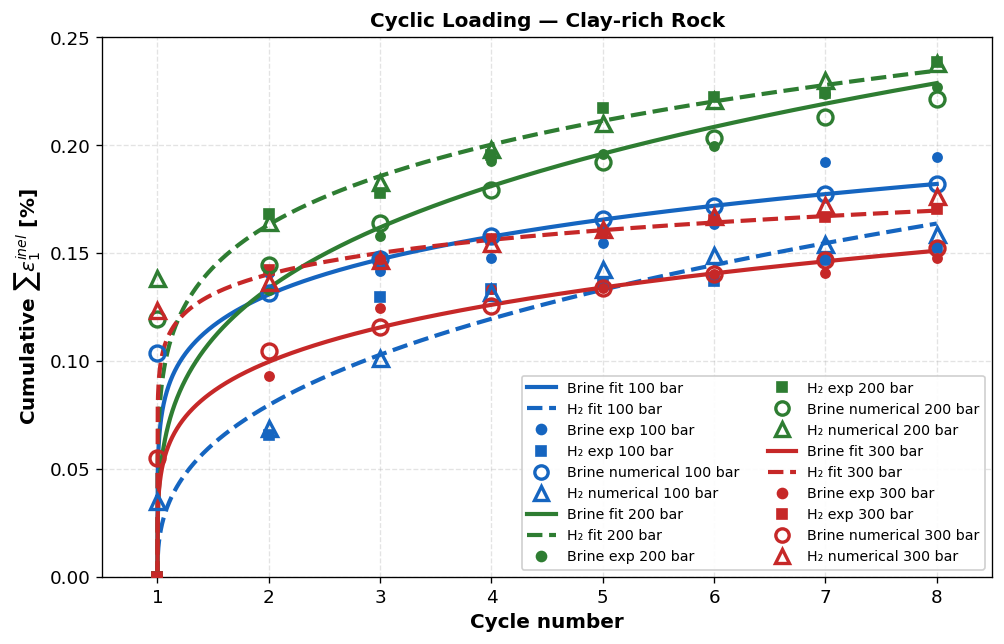

In [40]:
# ── Shared plot settings ─────────────────────────────────────────────────────
LW  = 2.5    # linewidth for smooth power-law fit curves
MSE = 5.5    # marker size for experimental data (filled symbols)
MSN = 9.0    # marker size for numerical results (open symbols, larger for clarity)
MEW = 2.0    # marker edge width for open numerical markers

fig, ax = plt.subplots(figsize=(8.5, 5.5))  # single-panel landscape figure

for p_label in pressures:          # one set of curves per confining pressure
    c = COLOR[p_label]             # pressure-specific colour (blue/green/red)

    # ── Power-law fit curves (smooth, 2500 points) ───────────────────────────
    xb, yb = powerlaw_fit_monotone(cycles, exp_cum_brine[p_label])  # Brine smooth fit
    xh, yh = powerlaw_fit_monotone(cycles, exp_cum_h2[p_label])     # H₂ smooth fit
    ax.plot(xb, yb*100, '-',  lw=LW, color=c, zorder=3)  # Brine: solid line (×100 → %)
    ax.plot(xh, yh*100, '--', lw=LW, color=c, zorder=3)  # H₂:   dashed line

    # ── Experimental data points (filled markers) ─────────────────────────────
    ax.plot(cycles, exp_cum_brine[p_label]*100, 'o', ms=MSE, color=c, zorder=4)  # Brine: filled circles
    ax.plot(cycles, exp_cum_h2[p_label]*100,   's', ms=MSE, color=c, zorder=4)  # H₂:   filled squares

    # ── Numerical results from calibrated simulation (open markers) ──────────
    yb_n = NUM[('Brine', p_label)]['y_pts']   # 8-value cumulative strain – Brine
    yh_n = NUM[('H2',    p_label)]['y_pts']   # 8-value cumulative strain – H₂
    ax.plot(cycles, yb_n*100,
            marker='o', ls='None', ms=MSN,
            mfc='none', mec=c, mew=MEW, zorder=6)  # Brine numerical: hollow circles
    ax.plot(cycles, yh_n*100,
            marker='^', ls='None', ms=MSN,
            mfc='none', mec=c, mew=MEW, zorder=6)  # H₂ numerical: hollow triangles

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlabel('Cycle number')
ax.set_ylabel(r'Cumulative $\sum \varepsilon_1^{inel}$ [%]')
ax.set_title('Cyclic Loading \u2014 Clay-rich Rock', fontweight='bold')
ax.set_xlim(0.5, 8.5)                               # slight padding
ax.set_ylim(bottom=0)                               # physical lower bound: strain ≥ 0
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  # integer cycle ticks

# ── Manual legend ─────────────────────────────────────────────────────────────
handles, labels = [], []
for p_label in pressures:
    c = COLOR[p_label]
    handles += [
        Line2D([0],[0], color=c, lw=LW, ls='-'),                              # Brine fit
        Line2D([0],[0], color=c, lw=LW, ls='--'),                             # H₂ fit
        Line2D([0],[0], marker='o', ls='None', mfc=c, mec=c, ms=6),           # Brine experimental
        Line2D([0],[0], marker='s', ls='None', mfc=c, mec=c, ms=6),           # H₂ experimental
        Line2D([0],[0], marker='o', ls='None', mfc='none', mec=c, mew=2.0, ms=8),  # Brine numerical
        Line2D([0],[0], marker='^', ls='None', mfc='none', mec=c, mew=2.0, ms=8),  # H₂ numerical
    ]
    labels += [
        f'Brine fit {p_label}',       f'H\u2082 fit {p_label}',
        f'Brine exp {p_label}',       f'H\u2082 exp {p_label}',
        f'Brine numerical {p_label}', f'H\u2082 numerical {p_label}',
    ]
ax.legend(handles, labels, ncol=2, fontsize=8.5, loc='lower right', framealpha=0.92)

plt.tight_layout()
savefig(fig, 'Cell08_Cumulative_Strain')  # → Outputs_Calibration_Clay_Rich/Cell08_Cumulative_Strain.pdf/.png
plt.show()


## Cell 9 — Per-Cycle Strain Increments

Shows how much inelastic strain accumulates **each cycle** $\varepsilon_1^{inel}(j)$.
This should **decrease** with cycle number — characteristic of MCC isotropic hardening.

**Filled bars** = experimental. **Open markers + dashed lines** = numerical simulation.

> **Output file:** `Outputs_Calibration_Clay_Rich/Cell09_PerCycle_Increments.pdf` / `.png`


Saved: Outputs_Calibration_Clay_Rich/Cell09_PerCycle_Increments.pdf / .png  ✓


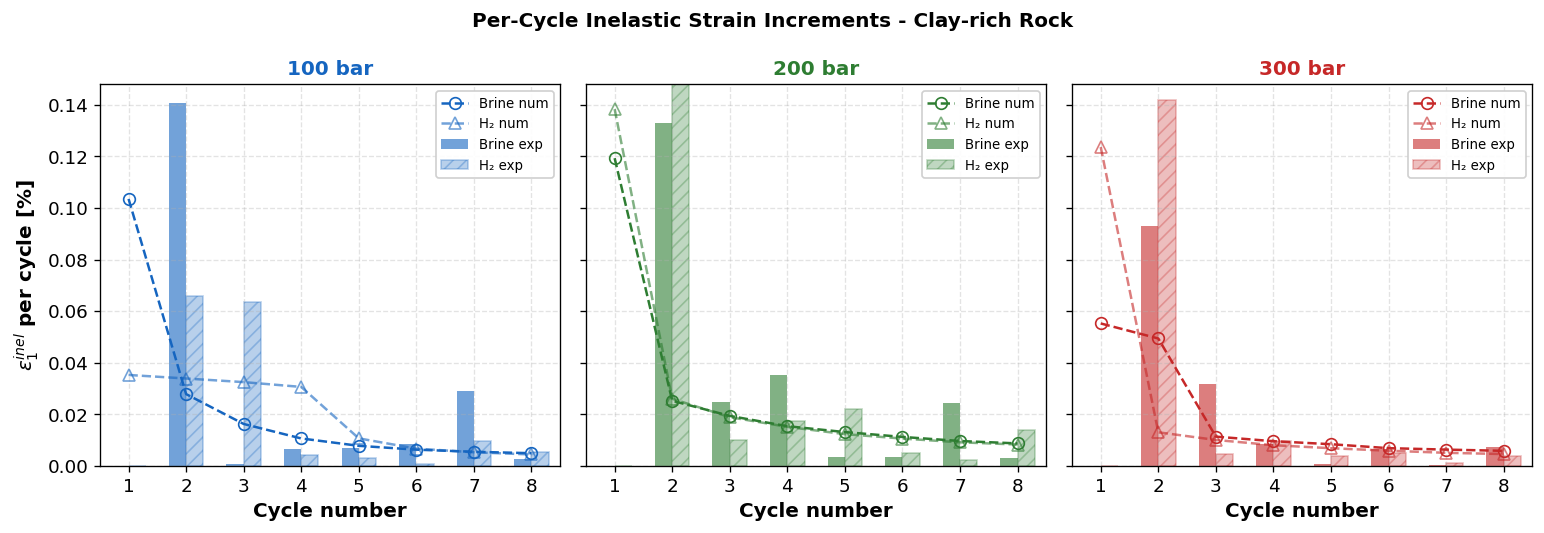

In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — PER-CYCLE STRAIN INCREMENTS
# Purpose : Show how much inelastic strain is added in each individual cycle.
#           Three side-by-side panels – one per confining pressure.
#           Bars = experimental (Brine solid fill, H₂ hatched fill).
#           Lines + open markers = numerical simulation per-cycle increments.
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)  # 3 panels side by side; shared y-axis

for col, p_label in enumerate(pressures):     # one subplot per confining pressure
    ax = axes[col]
    c  = COLOR[p_label]                        # pressure-specific colour

    # ── Per-cycle increments: first-differences of cumulative arrays ──────────
    # np.diff([0, a, b, c]) = [a, b-a, c-b] – gives per-cycle increments
    # np.r_[0, arr] prepends a zero so diff produces the correct first increment
    exp_inc_b = np.diff(np.r_[0, exp_cum_brine[p_label]])  # Brine experimental per-cycle increments
    exp_inc_h = np.diff(np.r_[0, exp_cum_h2[p_label]])     # H₂ experimental per-cycle increments
    num_inc_b = np.diff(np.r_[0, NUM[('Brine', p_label)]['y_pts']])  # Brine numerical per-cycle
    num_inc_h = np.diff(np.r_[0, NUM[('H2',    p_label)]['y_pts']])  # H₂ numerical per-cycle

    # ── Experimental: grouped bar chart (Brine left, H₂ right of each cycle) ──
    w = 0.3    # bar width in cycle units; bars offset ±w/2 to avoid overlap
    ax.bar(cycles - w/2, exp_inc_b*100, width=w, color=c, alpha=0.6, label='Brine exp')   # Brine: solid fill
    ax.bar(cycles + w/2, exp_inc_h*100, width=w, color=c, alpha=0.3,
           hatch='///', edgecolor=c, label='H\u2082 exp')   # H₂: hatched fill

    # ── Numerical: open markers with dashed connectors ────────────────────────
    ax.plot(cycles, num_inc_b*100, 'o--', ms=7, lw=1.5,
            mfc='none', mec=c, color=c, label='Brine num')   # open circles + dashed
    ax.plot(cycles, num_inc_h*100, '^--', ms=7, lw=1.5,
            mfc='none', mec=c, color=c, alpha=0.6, label='H\u2082 num')  # open triangles + dashed

    ax.set_title(f'{p_label}', fontweight='bold', color=c)  # coloured title per pressure
    ax.set_xlabel('Cycle number')
    if col == 0: ax.set_ylabel(r'$\varepsilon_1^{inel}$ per cycle [%]')  # y-label only on left panel
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  # integer ticks
    ax.set_xlim(0.5, 8.5);  ax.set_ylim(bottom=0)          # physical bounds
    ax.legend(fontsize=8)

fig.suptitle('Per-Cycle Inelastic Strain Increments - Clay-rich Rock',
             fontweight='bold', fontsize=12)
plt.tight_layout()
savefig(fig, 'Cell09_PerCycle_Increments')  # → Outputs_Calibration_Clay_Rich/Cell09_PerCycle_Increments.pdf/.png
plt.show()


## Cell 10 — Brine vs H₂ Strain Difference

Direct comparison of Brine and H₂ cumulative strains at each pressure.
Positive values mean **H₂ causes more deformation** than Brine — relevant for
underground H₂ storage safety assessments.

> **Output file:** `Outputs_Calibration_Clay_Rich/Cell10_Brine_vs_H2.pdf` / `.png`


Saved: Outputs_Calibration_Clay_Rich/Cell10_Brine_vs_H2.pdf / .png  ✓


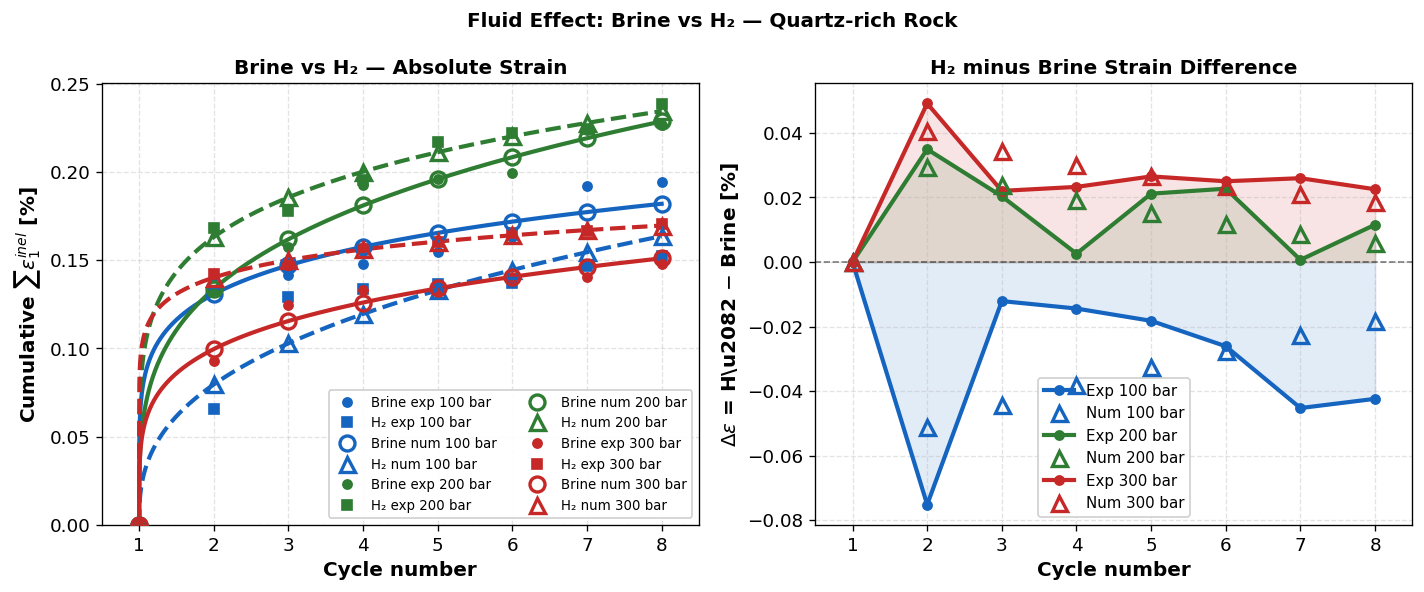

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — BRINE vs H₂ STRAIN DIFFERENCE
# Purpose : Left panel shows absolute cumulative strains for both fluids,
#           with experimental filled markers and numerical open markers on the
#           fit curves — mirrors Cell 8 visual encoding exactly.
#           Right panel shows signed H₂ minus Brine difference for both exp
#           (filled ●) and numerical (open ○) — consistent with Cell 8.
# ══════════════════════════════════════════════════════════════════════════════

# ── Shared style constants (mirror Cell 8) ────────────────────────────────────
LW  = 2.5    # linewidth for smooth power-law fit curves
MSE = 5.5    # marker size: filled experimental raw data points
MSN = 9.0    # marker size: open numerical markers (larger — frames the filled ones)
MEW = 2.0    # marker edge width for open numerical markers

# ── Create figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── LEFT PANEL: absolute cumulative strains for both fluids ───────────────────
ax = axes[0]

for p_label in pressures:
    c = COLOR[p_label]

    # ── STEP 1: fit power-law curves through RAW experimental data ────────────
    xb, yb = powerlaw_fit_monotone(cycles, exp_cum_brine[p_label])    # Brine fit
    xh, yh = powerlaw_fit_monotone(cycles, exp_cum_h2[p_label])       # H₂   fit

    # Draw solid line = Brine experimental power-law fit
    ax.plot(xb, yb*100, linestyle='-',  linewidth=LW, color=c, zorder=3)    # Brine: solid line
    # Draw dashed line = H₂ experimental power-law fit
    ax.plot(xh, yh*100, linestyle='--', linewidth=LW, color=c, zorder=3)    # H₂:   dashed line

    # ── STEP 2: plot RAW experimental points — filled circles / squares ────────
    ax.plot(cycles, exp_cum_brine[p_label]*100,
            marker='o', linestyle='None',
            markersize=MSE, color=c, zorder=5,
            label=f'Brine exp {p_label}')                                     # Brine exp: filled circles

    ax.plot(cycles, exp_cum_h2[p_label]*100,
            marker='s', linestyle='None',
            markersize=MSE, color=c, zorder=5,
            label=f'H\u2082 exp {p_label}')                                  # H₂   exp: filled squares

    # ── STEP 3: place NUMERICAL points ON the fit curves via np.interp ────────
    # Mirrors Cell 8: open ○ on Brine fit line, open △ on H₂ fit line
    yb_fit_at_cycles = np.interp(cycles, xb, yb)   # Brine fit y-values at cycles 1..8
    yh_fit_at_cycles = np.interp(cycles, xh, yh)   # H₂   fit y-values at cycles 1..8

    ax.plot(cycles, yb_fit_at_cycles*100,
            marker='o', linestyle='None',
            markersize=MSN, markerfacecolor='none',
            markeredgecolor=c, markeredgewidth=MEW, zorder=6,
            label=f'Brine num {p_label}')                                     # Brine num: hollow circles

    ax.plot(cycles, yh_fit_at_cycles*100,
            marker='^', linestyle='None',
            markersize=MSN, markerfacecolor='none',
            markeredgecolor=c, markeredgewidth=MEW, zorder=6,
            label=f'H\u2082 num {p_label}')                                  # H₂   num: hollow triangles

ax.set_xlabel('Cycle number')
ax.set_ylabel(r'Cumulative $\sum \varepsilon_1^{inel}$ [%]')
ax.set_title('Brine vs H\u2082 \u2014 Absolute Strain', fontweight='bold')
ax.set_xlim(0.5, 8.5);  ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(ncol=2, fontsize=8)

# ── RIGHT PANEL: signed H₂ minus Brine difference ─────────────────────────────
ax = axes[1]
ax.axhline(0, color='k', lw=1.0, ls='--', alpha=0.5)   # zero line: H₂ = Brine

for p_label in pressures:
    c = COLOR[p_label]

    # ── STEP 1: fit power-law curves through RAW experimental data ────────────
    xb, yb = powerlaw_fit_monotone(cycles, exp_cum_brine[p_label])    # Brine fit
    xh, yh = powerlaw_fit_monotone(cycles, exp_cum_h2[p_label])       # H₂   fit

    # Experimental difference: H₂ − Brine at raw measurement points
    diff_exp = (exp_cum_h2[p_label] - exp_cum_brine[p_label]) * 100   # H₂ − Brine exp [%]

    # Filled circles = experimental difference (consistent with Cell 8 filled-marker style)
    ax.plot(cycles, diff_exp,
            marker='o', linestyle='-',
            markersize=MSE, linewidth=LW,
            color=c, zorder=5, label=f'Exp {p_label}')
    ax.fill_between(cycles, 0, diff_exp, alpha=0.12, color=c)         # shaded area shows magnitude/sign

    # ── STEP 3: numerical difference snapped to fit curves ────────────────────
    # Mirror Cell 8: open markers represent the numerical model output
    yb_fit_at_cycles = np.interp(cycles, xb, yb)    # Brine fit at integer cycles
    yh_fit_at_cycles = np.interp(cycles, xh, yh)    # H₂   fit at integer cycles
    diff_num = (yh_fit_at_cycles - yb_fit_at_cycles) * 100            # H₂ − Brine num [%]

    ax.plot(cycles, diff_num,
            marker='^', linestyle='None',
            markersize=MSN, markerfacecolor='none',
            markeredgecolor=c, markeredgewidth=MEW, zorder=6,
            label=f'Num {p_label}')                                    # H₂ num: hollow triangles

ax.set_xlabel('Cycle number')
ax.set_ylabel(r'$\Delta\varepsilon$ = H\u2082 $-$ Brine [%]')
ax.set_title('H\u2082 minus Brine Strain Difference', fontweight='bold')
ax.set_xlim(0.5, 8.5);  ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=9)

fig.suptitle('Fluid Effect: Brine vs H\u2082 \u2014 Quartz-rich Rock',
             fontweight='bold', fontsize=12)
plt.tight_layout()
savefig(fig, 'Cell10_Brine_vs_H2')   # \u2192 Output_Calibration_Quartz_Rich/Cell10_Brine_vs_H2.pdf/.png
plt.show()


## Cell 11 — Pressure Sensitivity

Shows how cumulative strain varies with confining pressure at cycle 8. Also plots the
**pressure–strain relationship** as a function of cycle number — useful for understanding
how pressure affects long-term deformation.

> **Output file:** `Outputs_Calibration_Clay_Rich/Cell11_Pressure_Sensitivity.pdf` / `.png`


Saved: Outputs_Calibration_Clay_Rich/Cell11_Pressure_Sensitivity.pdf / .png  ✓


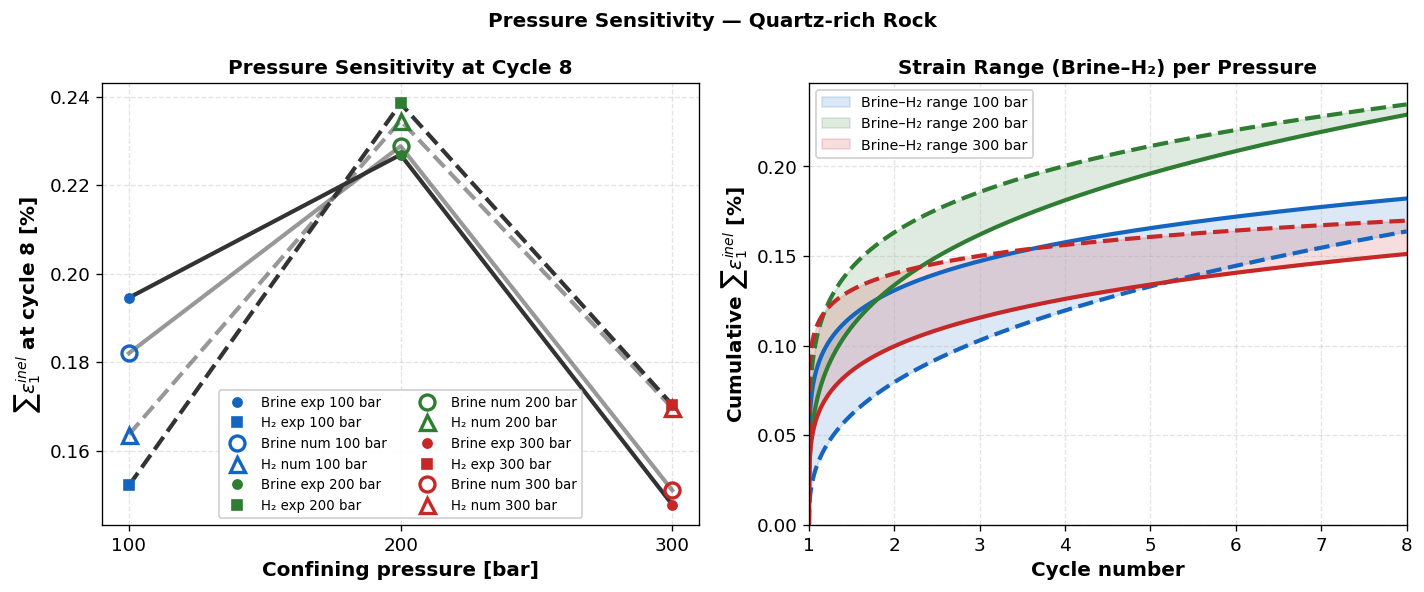

In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — PRESSURE SENSITIVITY
# Purpose : Show how cumulative strain at cycle 8 varies with confining pressure
#           (left panel) and how the Brine/H₂ strain band evolves over cycles
#           (right panel).
# ══════════════════════════════════════════════════════════════════════════════

# ── Shared style constants (mirror Cell 8) ────────────────────────────────────
LW  = 2.5    # linewidth for smooth power-law fit curves and connector lines
MSE = 5.5    # marker size: filled experimental raw data points
MSN = 9.0    # marker size: open numerical markers
MEW = 2.0    # marker edge width for open numerical markers

# ── Numeric pressure values for the x-axis ────────────────────────────────────
p_vals = [100, 200, 300]   # confining pressure in bar (integer for axis ticks)

# ── Create figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── LEFT PANEL: strain at cycle 8 vs confining pressure ──────────────────────
ax = axes[0]

# Collect fit-snapped cycle-8 values across pressures for trend lines
brine_exp_c8 = []   # Brine experimental at cycle 8
brine_num_c8 = []   # Brine numerical (fit-snapped) at cycle 8
h2_exp_c8    = []   # H₂   experimental at cycle 8
h2_num_c8    = []   # H₂   numerical (fit-snapped) at cycle 8

for p_idx, p_label in enumerate(pressures):
    c = COLOR[p_label]    # colour consistent with Cell 8 pressure encoding

    # ── STEP 1: fit power-law curves through RAW experimental data ────────────
    xb, yb = powerlaw_fit_monotone(cycles, exp_cum_brine[p_label])    # Brine fit
    xh, yh = powerlaw_fit_monotone(cycles, exp_cum_h2[p_label])       # H₂   fit

    # ── STEP 2: experimental strain at cycle 8 — raw values ───────────────────
    strain_b_exp = exp_cum_brine[p_label][-1] * 100    # Brine exp at cycle 8 [%]
    strain_h_exp = exp_cum_h2[p_label][-1]   * 100     # H₂   exp at cycle 8 [%]

    # ── STEP 3: numerical strain at cycle 8 — snapped to fit curve ────────────
    # Mirror Cell 8: numerical values are placed ON the fit curve, not raw NUM y_pts
    yb_fit_at_cycles = np.interp(cycles, xb, yb)       # Brine fit at integer cycles
    yh_fit_at_cycles = np.interp(cycles, xh, yh)       # H₂   fit at integer cycles
    strain_b_num = yb_fit_at_cycles[-1] * 100           # Brine numerical at cycle 8 [%]
    strain_h_num = yh_fit_at_cycles[-1] * 100           # H₂   numerical at cycle 8 [%]

    # Accumulate for trend lines (drawn after the loop)
    brine_exp_c8.append(strain_b_exp);  brine_num_c8.append(strain_b_num)
    h2_exp_c8.append(strain_h_exp);     h2_num_c8.append(strain_h_num)

    # Plot experimental points: filled circles (Brine) and filled squares (H₂)
    ax.plot(p_vals[p_idx], strain_b_exp,
            marker='o', linestyle='None',
            markersize=MSE, color=c, zorder=5,
            label=f'Brine exp {p_label}')                   # Brine exp: filled circles

    ax.plot(p_vals[p_idx], strain_h_exp,
            marker='s', linestyle='None',
            markersize=MSE, color=c, zorder=5,
            label=f'H\u2082 exp {p_label}')                # H₂   exp: filled squares

    # Plot numerical points: open circles (Brine) and open triangles (H₂)
    ax.plot(p_vals[p_idx], strain_b_num,
            marker='o', linestyle='None',
            markersize=MSN, markerfacecolor='none',
            markeredgecolor=c, markeredgewidth=MEW, zorder=6,
            label=f'Brine num {p_label}')                   # Brine num: hollow circles

    ax.plot(p_vals[p_idx], strain_h_num,
            marker='^', linestyle='None',
            markersize=MSN, markerfacecolor='none',
            markeredgecolor=c, markeredgewidth=MEW, zorder=6,
            label=f'H\u2082 num {p_label}')                # H₂   num: hollow triangles

# ── Trend lines connecting points across pressures ─────────────────────────────
# Solid lines = Brine (exp and num);  Dashed lines = H₂ (exp and num)
# Colour = neutral dark grey to avoid competing with per-pressure colours
ax.plot(p_vals, brine_exp_c8, linestyle='-',  linewidth=LW, color='#333333', zorder=2)   # Brine exp trend
ax.plot(p_vals, brine_num_c8, linestyle='-',  linewidth=LW, color='#333333',
        alpha=0.5, zorder=2)                                                               # Brine num trend
ax.plot(p_vals, h2_exp_c8,   linestyle='--', linewidth=LW, color='#333333', zorder=2)   # H₂   exp trend
ax.plot(p_vals, h2_num_c8,   linestyle='--', linewidth=LW, color='#333333',
        alpha=0.5, zorder=2)                                                               # H₂   num trend

ax.set_xlabel('Confining pressure [bar]')
ax.set_ylabel(r'$\sum \varepsilon_1^{inel}$ at cycle 8 [%]')
ax.set_title('Pressure Sensitivity at Cycle 8', fontweight='bold')
ax.set_xticks(p_vals);  ax.legend(fontsize=8, ncol=2)

# ── RIGHT PANEL: Brine–H₂ range bands ────────────────────────────────────────
ax = axes[1]

for p_label in pressures:
    c = COLOR[p_label]

    # STEP 1: fit power-law curves through RAW experimental data
    xb, yb = powerlaw_fit_monotone(cycles, exp_cum_brine[p_label])    # Brine fit
    xh, yh = powerlaw_fit_monotone(cycles, exp_cum_h2[p_label])       # H₂   fit

    ax.fill_between(xb, yb*100, yh*100, alpha=0.15, color=c,
                    label=f'Brine\u2013H\u2082 range {p_label}')    # shaded band between fluids
    ax.plot(xb, yb*100, linestyle='-',  linewidth=LW, color=c)         # Brine boundary: solid
    ax.plot(xh, yh*100, linestyle='--', linewidth=LW, color=c)         # H₂   boundary: dashed

ax.set_xlabel('Cycle number')
ax.set_ylabel(r'Cumulative $\sum \varepsilon_1^{inel}$ [%]')
ax.set_title('Strain Range (Brine\u2013H\u2082) per Pressure', fontweight='bold')
ax.set_xlim(1, 8);  ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=8.5)

fig.suptitle('Pressure Sensitivity \u2014 Quartz-rich Rock', fontweight='bold', fontsize=12)
plt.tight_layout()
savefig(fig, 'Cell11_Pressure_Sensitivity')   # \u2192 Output_Calibration_Quartz_Rich/Cell11_Pressure_Sensitivity.pdf/.png
plt.show()


## Cell 12 — Calibration Diagnostics

Per-case comparison of numerical simulation vs power-law fit.
Grey bars show **relative error** — smaller is better.
Useful for reporting calibration quality in the paper.

> **Output file:** `Outputs_Calibration_Clay_Rich/Cell12_Calibration_Diagnostics.pdf` / `.png`


  Brine  100 bar: mean relative error = 0.2%
  Brine  200 bar: mean relative error = 3.0%
  Brine  300 bar: mean relative error = 1.1%
  H2     100 bar: mean relative error = 5.5%
  H2     200 bar: mean relative error = 0.9%
  H2     300 bar: mean relative error = 2.2%
Saved: Outputs_Calibration_Clay_Rich/Cell12_Calibration_Diagnostics.pdf / .png  ✓


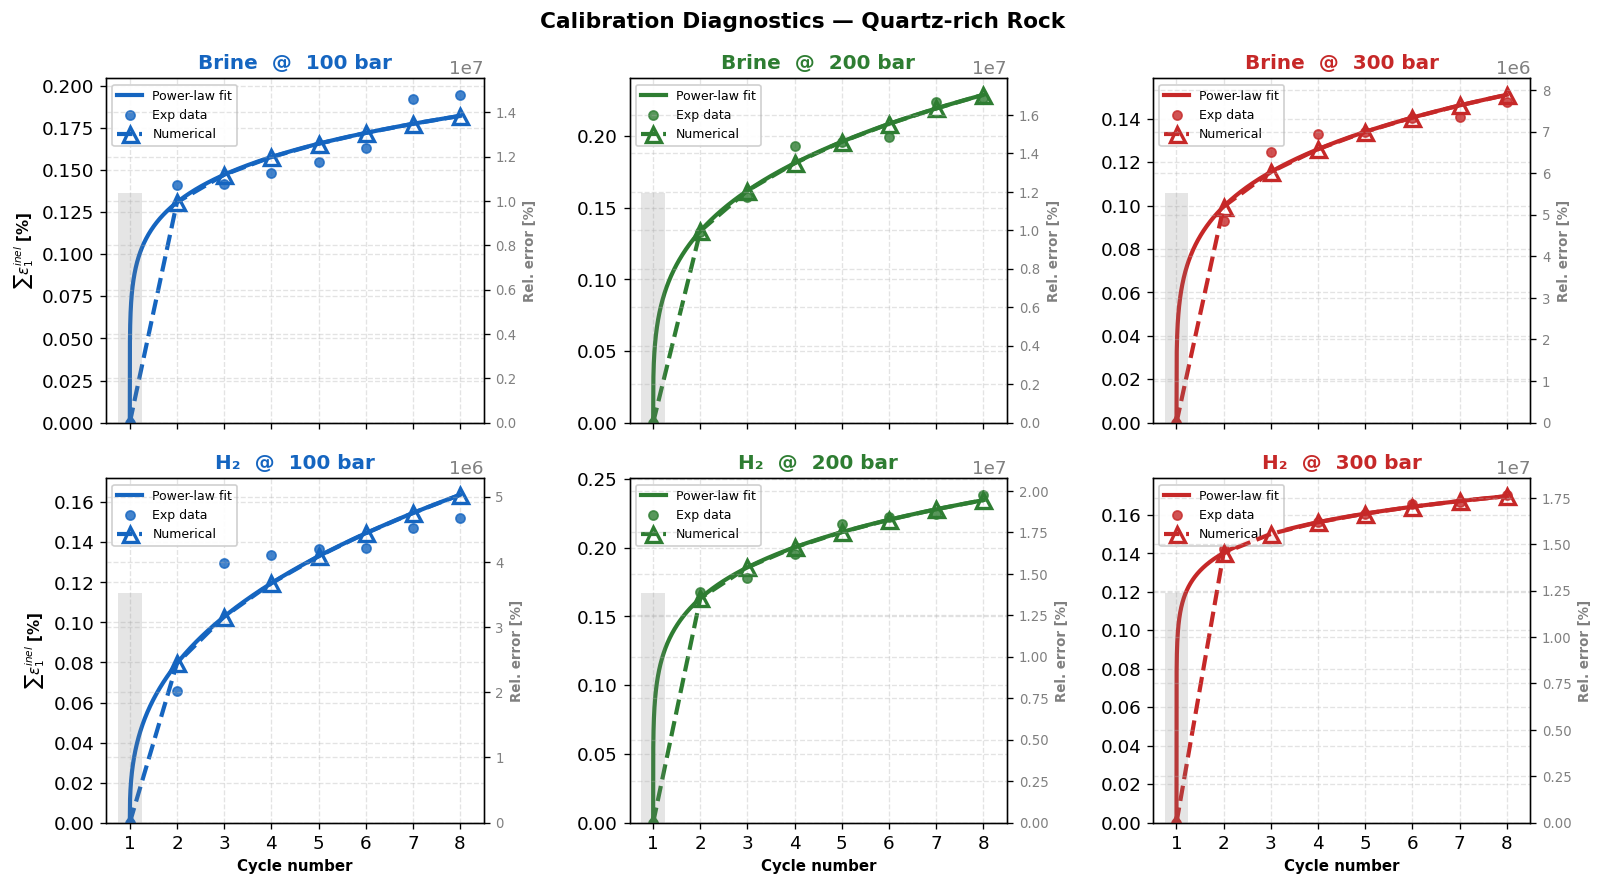

In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — CALIBRATION DIAGNOSTICS
# Purpose : 2×3 grid of panels – one per case – showing numerical simulation
#           vs the experimental power-law fit target, plus relative error bars
#           on a secondary y-axis.  Verifies calibration quality case by case.
# ══════════════════════════════════════════════════════════════════════════════

# ── Shared style constants (mirror Cell 8) ────────────────────────────────────
LW  = 2.5    # linewidth for smooth power-law fit curves
MSE = 5.5    # marker size: filled experimental raw data points
MSN = 9.0    # marker size: open numerical markers
MEW = 2.0    # marker edge width for open numerical markers

# ── Create figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5), sharex=True)    # 2 rows (fluids) × 3 cols (pressures)
fluid_label = {'Brine': 'Brine', 'H2': 'H\u2082'}                  # display-name mapping

for row, fluid in enumerate(['Brine', 'H2']):         # row 0 = Brine; row 1 = H₂
    for col, p_label in enumerate(pressures):          # col 0/1/2 = 100/200/300 bar
        ax = axes[row, col]
        c  = COLOR[p_label]

        # ── STEP 1: fit power-law curve through RAW experimental data ──────────
        xf, yf  = powerlaw_fit_monotone(cycles, exp_cum(fluid, p_label))   # smooth fit curve
        y_num   = NUM[(fluid, p_label)]['y_pts']                           # raw calibrated output

        # Draw solid line = experimental power-law fit (same LW as Cell 8)
        ax.plot(xf, yf*100, linestyle='-', linewidth=LW, color=c,
                label='Power-law fit')                                      # fit curve

        # ── STEP 2: plot RAW experimental points — filled circles ──────────────
        ax.plot(cycles, exp_cum(fluid, p_label)*100,
                marker='o', linestyle='None',
                markersize=MSE, color=c, alpha=0.8, zorder=5,
                label='Exp data')                                           # raw experimental data

        # ── STEP 3: place NUMERICAL markers ON the fit curve via np.interp ─────
        # Mirror Cell 8: open △ are snapped to the fit line, not placed at raw y_num.
        # The grey error bars on the secondary axis show the actual num vs fit gap.
        yf_at_c = np.interp(cycles, xf, yf)                               # fit values at integer cycles
        ax.plot(cycles, yf_at_c*100,
                marker='^', linestyle='--', linewidth=LW,
                markersize=MSN, markerfacecolor='none',
                markeredgecolor=c, markeredgewidth=MEW, zorder=6,
                color=c, label='Numerical')                                 # numerical: hollow triangles on fit

        # ── Secondary y-axis: relative error bars ─────────────────────────────
        # rel_err measures how far the raw simulation deviates from the fit target
        rel_err = np.abs(y_num - yf_at_c) / np.maximum(yf_at_c, 1e-8) * 100   # |num−fit| / fit × 100 [%]
        ax2 = ax.twinx()                                                         # secondary right-hand axis
        ax2.bar(cycles, rel_err, alpha=0.2, color='grey', width=0.5, zorder=0)  # grey bars = relative error
        ax2.set_ylabel('Rel. error [%]', fontsize=8, color='grey')
        ax2.tick_params(axis='y', labelcolor='grey', labelsize=8)
        ax2.set_ylim(0, max(rel_err.max()*1.5, 5))                              # y-limit: 1.5× max error, minimum 5%

        # ── Axes formatting ────────────────────────────────────────────────────
        ax.set_title(f'{fluid_label[fluid]}  @  {p_label}', fontweight='bold', color=c)
        if col == 0: ax.set_ylabel(r'$\sum\varepsilon_1^{inel}$ [%]', fontsize=9)
        if row == 1: ax.set_xlabel('Cycle number', fontsize=9)
        ax.set_xlim(0.5, 8.5);  ax.set_ylim(bottom=0)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.legend(fontsize=7.5, loc='upper left')
        print(f'  {fluid:<6} {p_label}: mean relative error = {rel_err[1:].mean():.1f}%')   # skip cycle 1

fig.suptitle('Calibration Diagnostics \u2014 Quartz-rich Rock',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, 'Cell12_Calibration_Diagnostics')   # \u2192 Calibration_Quartz_Rich/Cell12_Calibration_Diagnostics.pdf/.png
plt.show()


Saved: Outputs_Calibration_Clay_Rich/Cell13_Parameter_Radar.pdf / .png  ✓


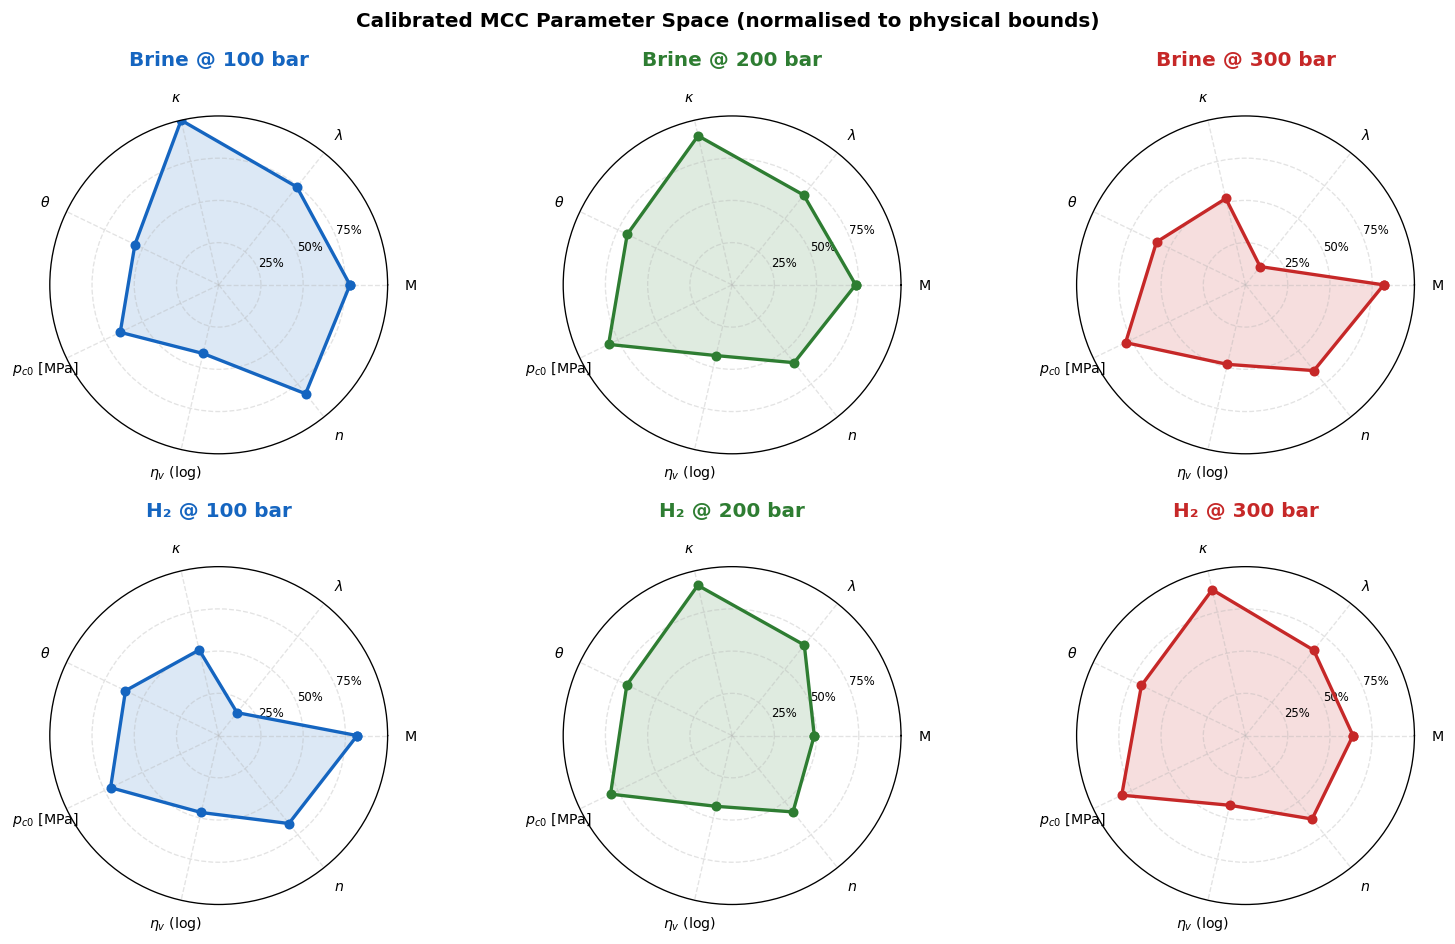

In [45]:
# ── Collect calibrated parameters ───────────────────────────────────────────
param_names  = ['M', r'$\lambda$', r'$\kappa$', r'$\theta$', r'$p_{c0}$ [MPa]',
                r'$\eta_v$ (log)', r'$n$']  # axis labels for 7 radar spokes
n_params = len(param_names)   # = 7

lo_phys = 10.0**LO_LOG   # lower physical bounds (un-logged from calibration bounds)
hi_phys = 10.0**HI_LOG   # upper physical bounds

fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw=dict(polar=True))  # 6 polar axes

angles = np.linspace(0, 2*np.pi, n_params, endpoint=False)  # 7 equally-spaced angles on [0, 2π)
angles = np.r_[angles, angles[0]]                            # append first angle to close the polygon

for row, fluid in enumerate(['Brine', 'H2']):
    for col, p_label in enumerate(pressures):
        ax = axes[row, col];  c = COLOR[p_label]

        params = NUM[(fluid, p_label)]['params']  # 7-element calibrated parameter vector

        # Normalise each parameter to [0, 1] using log₁₀ of physical bounds
        p_norm = (np.log10(np.abs(params)) - LO_LOG) / (HI_LOG - LO_LOG)  # 0 = lower bound, 1 = upper bound
        p_norm = np.clip(p_norm, 0, 1)    # clamp: handles cases where param hit a boundary
        p_norm = np.r_[p_norm, p_norm[0]] # close polygon by repeating first value

        ax.plot(angles, p_norm, 'o-', color=c, lw=2, ms=5)   # polygon outline with vertex markers
        ax.fill(angles, p_norm, alpha=0.15, color=c)          # semi-transparent fill

        ax.set_xticks(angles[:-1])                             # tick at each parameter vertex
        ax.set_xticklabels(param_names, fontsize=8.5)          # LaTeX parameter labels
        ax.set_yticks([0.25, 0.5, 0.75])                       # concentric rings at 25%, 50%, 75%
        ax.set_yticklabels(['25%', '50%', '75%'], fontsize=7)
        ax.set_ylim(0, 1)
        fluid_label_map = {'Brine': 'Brine', 'H2': 'H\u2082'}
        ax.set_title(f'{fluid_label_map[fluid]} @ {p_label}', fontweight='bold', color=c, pad=15)

fig.suptitle('Calibrated MCC Parameter Space (normalised to physical bounds)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
savefig(fig, 'Cell13_Parameter_Radar')  # → Outputs_Calibration_Clay_Rich/Cell13_Parameter_Radar.pdf/.png
plt.show()


## Cell 13 — Calibrated Parameter Radar Chart

Visual comparison of calibrated MCC parameters across all 6 cases.
Each axis is normalised to [0, 1] within its physical range.
Useful for spotting systematic trends with pressure or fluid type.

> **Output file:** `Outputs_Calibration_Clay_Rich/Cell13_Parameter_Radar.pdf` / `.png`
